In [1]:
import pandas as pd
import numpy as np

import os
import re
import json
import random
import requests
from datetime import datetime
import json
import csv
from copy import deepcopy
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns
from skmultilearn.model_selection import iterative_train_test_split

In [2]:
# # ---------------- GPU SETUP ----------------
# import tensorflow as tf

# # List available GPUs
# gpus = tf.config.list_physical_devices('GPU')
# print("Num GPUs Available:", len(gpus))

# if gpus:
#     try:
#         # Enable memory growth for all GPUs (prevents TF from grabbing all memory)
#         for gpu in gpus:
#             tf.config.experimental.set_memory_growth(gpu, True)
#         logical_gpus = tf.config.list_logical_devices('GPU')
#         print(len(gpus), "Physical GPUs,", len(logical_gpus), "Logical GPUs")
#     except RuntimeError as e:
#         print(e)


In [3]:
JSON_MAP = {
    "m_17":"10_LateralMovement",
    "m_7":"ImpactScore",
    "m_18":"11_Collection",
    "m_13":"06_PrivilegeEscalation",
    "m_8":"01_Reconnaissance",
    "m_10":"03_InitialAccess",
    "m_14":"07_DefenseEvasion",
    "m_9":"02_ResourceDevelopment",
    "m_5":"BaseScore",
    "m_21":"14_Impact",
    "m_4":"Vector",
    "m_11":"04_Execution",
    "m_15":"08_CredentialAccess",
    "m_20":"13_Exfiltration",
    "m_6":"ExploitabilityScore",
    "m_19":"12_CommandAndControl",
    "m_16":"09_Discovery",
    "m_12":"05_Persistence"
}

JSON_MAP_REVERSE = {v: k for k, v in JSON_MAP.items()}

CATEGORY = {
    'Reconnaissance': [
                       'Active Scanning',
                       'Gather Victim Host Information', 
                       'Gather Victim Identity Information', 
                       'Gather Victim Network Information', 
                       'Gather Victim Org Information',
                       'Phishing for Information',
                       'Search Closed Sources',
                       'Search Open Technical Databases',
                       'Search Open Websites/Domains','Search Victim-Owned Websites'
    ],
    'Resource Development': [
                             'Acquire Infrastructure',
                             'Compromise Accounts',
                             'Compromise Infrastructure',
                             'Develop Capabilities',
                             'Establish Accounts',
                             'Obtain Capabilities',
                             'Stage Capabilities'  
    ],
    'Initial Access': [
                       'Drive-by Compromise',
                       'Exploit Public-Facing Application',
                       'External Remote Services',
                       'Hardware Additions',
                       'Phishing',
                       'Replication Through Removable Media',
                       'Supply Chain Compromise',
                       'Trusted Relationship',
                       'Valid Accounts'
    ],
    'Execution': [
                  'Command and Scripting Interpreter',
                  'Container Administration Command',
                  'Deploy Container',
                  'Exploitation for Client Execution',
                  'Inter-Process Communication',
                  'Native API',
                  'Scheduled Task/Job',
                  'Shared Modules',
                  'Software Deployment Tools',
                  'System Services',
                  'User Execution',
                  'Windows Management Instrumentation'
    ],
    'Persistence': [
                    'Account Manipulation',
                    'BITS Jobs',
                    'Boot or Logon Autostart Execution',
                    'Boot or Logon Initialization Scripts',
                    'Browser Extensions',
                    'Compromise Client Software Binary',
                    'Create Account',
                    'Create or Modify System Process',
                    'Event Triggered Execution',
                    'External Remote Services',
                    'Hijack Execution Flow',
                    'Implant Internal Image',
                    'Modify Authentication Process'
                    'Office Application Startup',
                    'Pre-OS Boot',
                    'Scheduled Task/Job',
                    'Server Software Component',
                    'Traffic Signaling',
                    'Valid Accounts'
    ],
    'Privilege Escalation': [
                             'Abuse Elevation Control Mechanism',
                             'Access Token Manipulation',
                             'Boot or Logon Autostart Execution',
                             'Boot or Logon Initialization Scripts',
                             'Create or Modify System Process',
                             'Domain Policy Modification',
                             'Escape to Host',
                             'Event Triggered Execution',
                             'Exploitation for Privilege Escalation',
                             'Hijack Execution Flow',
                             'Process Injectio',
                             'Scheduled Task/Job',
                             'Valid Accounts'
    ],
    'Defense Evasion': [
                        'Abuse Elevation Control Mechanism',
                        'Access Token Manipulation',
                        'BITS Jobs',
                        'Build Image on Host',
                        'Debugger Evasion',
                        'Deobfuscate/Decode Files or Information',
                        'Deploy Container',
                        'Direct Volume Access',
                        'Domain Policy Modification',
                        'Execution Guardrails',
                        'Exploitation for Defense Evasion',
                        'File and Directory Permissions Modification',
                        'Hide Artifacts',
                        'Hijack Execution Flow',
                        'Impair Defenses',
                        'Indicator Removal on Host',
                        'Indirect Command Execution',
                        'Masquerading',
                        'Modify Authentication Process',
                        'Modify Cloud Compute Infrastructure',
                        'Modify Registry',
                        'Modify System Image',
                        'Network Boundary Bridging',
                        'Obfuscated Files or Information',
                        'Plist File Modification',
                        'Pre-OS Boot',
                        'Process Injection',
                        'Reflective Code Loading',
                        'Rogue Domain Controller',
                        'Rootkit',
                        'Subvert Trust Controls',
                        'System Binary Proxy Execution',
                        'System Script Proxy Execution',
                        'Template Injection',
                        'Traffic Signaling',
                        'Trusted Developer Utilities Proxy Execution',
                        'Unused/Unsupported Cloud Regions',
                        'Use Alternate Authentication Material',
                        'Valid Accounts',
                        'Virtualization/Sandbox Evasion',
                        'Weaken Encryption',
                        'XSL Script Processing'
    ],
    'Credential Access': [
                          'Adversary-in-the-Middle',
                          'Brute Force',
                          'Credentials from Password Stores',
                          'Exploitation for Credential Access',
                          'Forced Authentication',
                          'Forge Web Credentials',
                          'Input Capture',
                          'Modify Authentication Process',
                          'Multi-Factor Authentication Interception',
                          'Multi-Factor Authentication Request Generation',
                          'Network Sniffing',
                          'OS Credential Dumping',
                          'Steal Application Access Token',
                          'Steal or Forge Kerberos Tickets',
                          'Steal Web Session Cookie',
                          'Unsecured Credentials',
    ],
    'Discovery': [
                  'Account Discovery',
                  'Application Window Discovery',
                  'Browser Bookmark Discovery',
                  'Cloud Infrastructure Discovery',
                  'Cloud Service Dashboard',
                  'Cloud Service Discovery',
                  'Cloud Storage Object Discovery',
                  'Container and Resource Discovery',
                  'Debugger Evasion',
                  'Domain Trust Discovery',
                  'File and Directory Discovery',
                  'Group Policy Discovery',
                  'Network Service Discovery',
                  'Network Share Discovery',
                  'Network Sniffing',
                  'Password Policy Discovery',
                  'Peripheral Device Discovery',
                  'Permission Groups Discovery',
                  'Process Discovery',
                  'Query Registry',
                  'Remote System Discovery',
                  'Software Discovery',
                  'System Information Discovery',
                  'System Location Discovery',
                  'System Network Configuration Discovery',
                  'System Network Connections Discovery',
                  'System Owner/User Discovery',
                  'System Service Discovery',
                  'System Time Discovery',
                  'Virtualization/Sandbox Evasion'
    ],
    'Lateral Movement': [
                         'Exploitation of Remote Services',
                         'Internal Spearphishing',
                         'Lateral Tool Transfer',
                         'Remote Service Session Hijacking',
                         'Remote Services',
                         'Replication Through Removable Media',
                         'Software Deployment Tools',
                         'Taint Shared Content',
                         'Use Alternate Authentication Material'
    ],
    'Collection': [
                   'Adversary-in-the-Middle',
                   'Archive Collected Data',
                   'Audio Capture',
                   'Automated Collection',
                   'Browser Session Hijacking',
                   'Clipboard Data',
                   'Data from Cloud Storage Object',
                   'Data from Configuration Repository',
                   'Data from Information Repositories',
                   'Data from Local System',
                   'Data from Network Shared Drive',
                   'Data from Removable Media',
                   'Data Staged',
                   'Email Collection',
                   'Input Capture', 
                   'Screen Capture',
                   'Video Capture'
    ],
    'Command and Control': [
                            'Application Layer Protocol',
                            'Communication Through Removable Media',
                            'Data Encoding',
                            'Data Obfuscation',
                            'Dynamic Resolution',
                            'Encrypted Channel', 
                            'Fallback Channels',
                            'Ingress Tool Transfer',
                            'Multi-Stage Channels',
                            'Non-Application Layer Protocol',
                            'Non-Standard Port',
                            'Protocol Tunneling',
                            'Proxy',
                            'Remote Access Software',
                            'Traffic Signaling',
                            'Web Service'
    ],
    'Exfiltration': [
                     'Automated Exfiltration', 
                     'Data Transfer Size Limits', 
                     'Exfiltration Over Alternative Protocol',
                     'Exfiltration Over C2 Channel', 
                     'Exfiltration Over Other Network Medium', 
                     'Exfiltration Over Physical Medium', 
                     'Exfiltration Over Web Service', 
                     'Scheduled Transfer', 
                     'Transfer Data to Cloud Account'
    ],
    'Impact': [
               'Account Access Removal',
               'Data Destruction',
               'Data Encrypted for Impact',
               'Data Manipulation',
               'Defacement',
               'Disk Wipe',
               'Endpoint Denial of Service',
               'Firmware Corruption',
               'Inhibit System Recovery',
               'Network Denial of Service',
               'Resource Hijacking',
               'Service Stop',
               'System Shutdown/Reboot'
    ]
}


TECHNIQUES = set()

for tactic in CATEGORY.keys():
  for technique in CATEGORY[tactic]:
    TECHNIQUES.add(technique)

In [4]:
len(TECHNIQUES)

192

In [5]:
def load_data_from_file(X_file, Y_file):
  X = pd.read_csv(X_file)
  Y = pd.read_csv(Y_file)
  
  Y = Y.astype(int)
  return (X, Y)

In [6]:
(X_train, y_train) = load_data_from_file('/kaggle/input/inputfile/X_train.csv', '/kaggle/input/inputfile/y_train.csv')

(X_train_extended, y_train_extended) = load_data_from_file('/kaggle/input/inputfile/final_extended_X_train.csv', '/kaggle/input/inputfile/final_extended_y_train.csv')

(X_test, y_test) = load_data_from_file('/kaggle/input/inputfile/X_test.csv', '/kaggle/input/inputfile/y_test.csv')

pd.set_option('display.max_colwidth', None)


In [7]:
def keep_relevant_techniques(Y, threshold):
  Y_count = Y.apply(np.sum, axis=0)
  columns_to_keep = Y_count[Y_count >= threshold].index
  return Y[columns_to_keep]

def remove_irrelevant_CVE(X, Y):
  is_CVE_used = Y.apply(lambda row: np.bitwise_or.reduce(row.values), axis = 1)
  indexes_to_keep = list(is_CVE_used[is_CVE_used == 1].index)
  X_final = X.loc[indexes_to_keep]
  Y_final = Y.loc[indexes_to_keep]

  X_final.reset_index(inplace=True, drop=True)
  Y_final.reset_index(inplace=True, drop=True)

  return (X_final, Y_final)

def filter_input_data(X, Y, threshold):
  return remove_irrelevant_CVE(X, keep_relevant_techniques(Y, threshold))



In [8]:
# 1. Start with extended data
X, Y = X_train_extended, y_train_extended

# 2. Apply filtering (removes rare techniques + irrelevant CVEs)
X, Y = filter_input_data(X, Y, threshold=20)

# 3. Convert to numpy arrays for iterative split
X_arr, Y_arr = X.to_numpy(), Y.values

# 4. Iterative stratified split (preserves label distribution)
from skmultilearn.model_selection import iterative_train_test_split

X_train_arr, y_train_arr, X_test_arr, y_test_arr = iterative_train_test_split(
    X_arr, Y_arr, test_size=0.2
)


In [9]:
X_train = pd.DataFrame(X_train_arr, columns=['Name', 'Text'])
X_test = pd.DataFrame(X_test_arr, columns=['Name', 'Text'])
y_train = pd.DataFrame(y_train_arr, columns=Y.columns)
y_test = pd.DataFrame(y_test_arr, columns=Y.columns)

In [10]:
def save_the_splitted_data_to_csv(X_train, X_test, y_train, y_test):
  X_train.to_csv('/kaggle/working/X_train.csv', index=False)
  X_test.to_csv('/kaggle/working/X_test.csv', index=False)
  y_train.to_csv('/kaggle/working/y_train.csv', index=False)
  y_test.to_csv('/kaggle/working/y_test.csv', index=False)

In [11]:
def plot_labels_count(Y):
  Y_count = Y.apply(np.sum, axis=0)
  ax = Y_count.sort_values(ascending=False).plot.bar(x='lab', y='val', rot=0)
  ax.set_xlabel("Techniques")
  ax.set_ylabel("Number of CVEs")
  plt.xticks(rotation=90)
  fig = plt.gcf()

  fig.set_size_inches(20.5, 8.5)

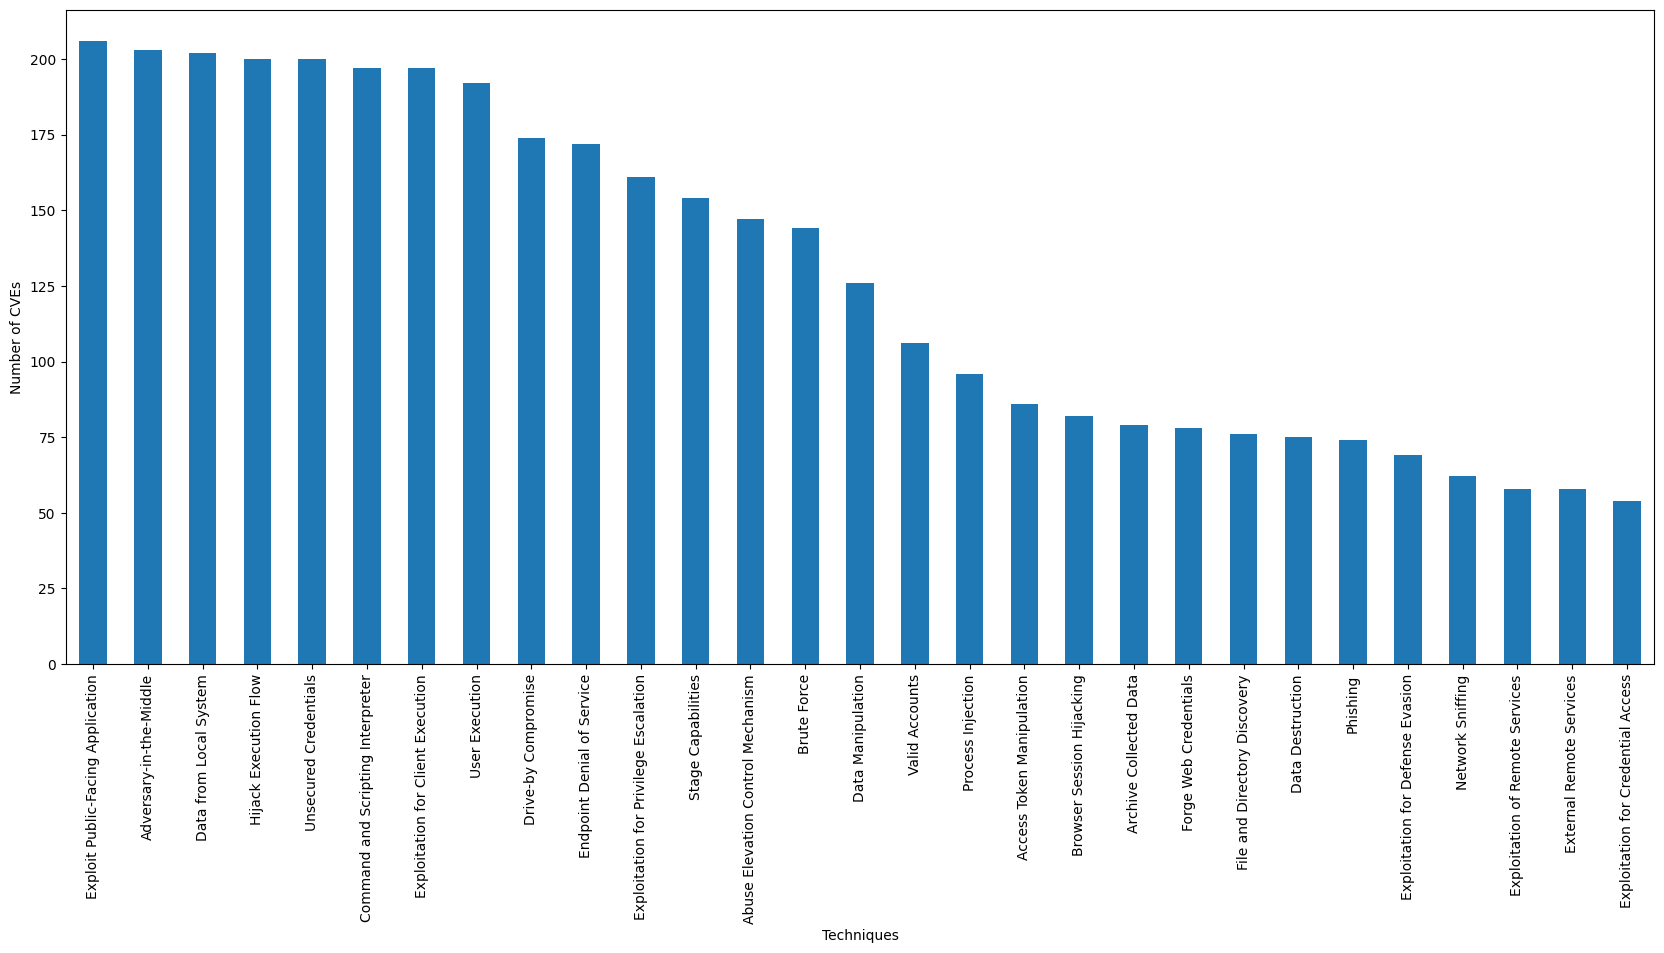

In [12]:
plot_labels_count(y_train)

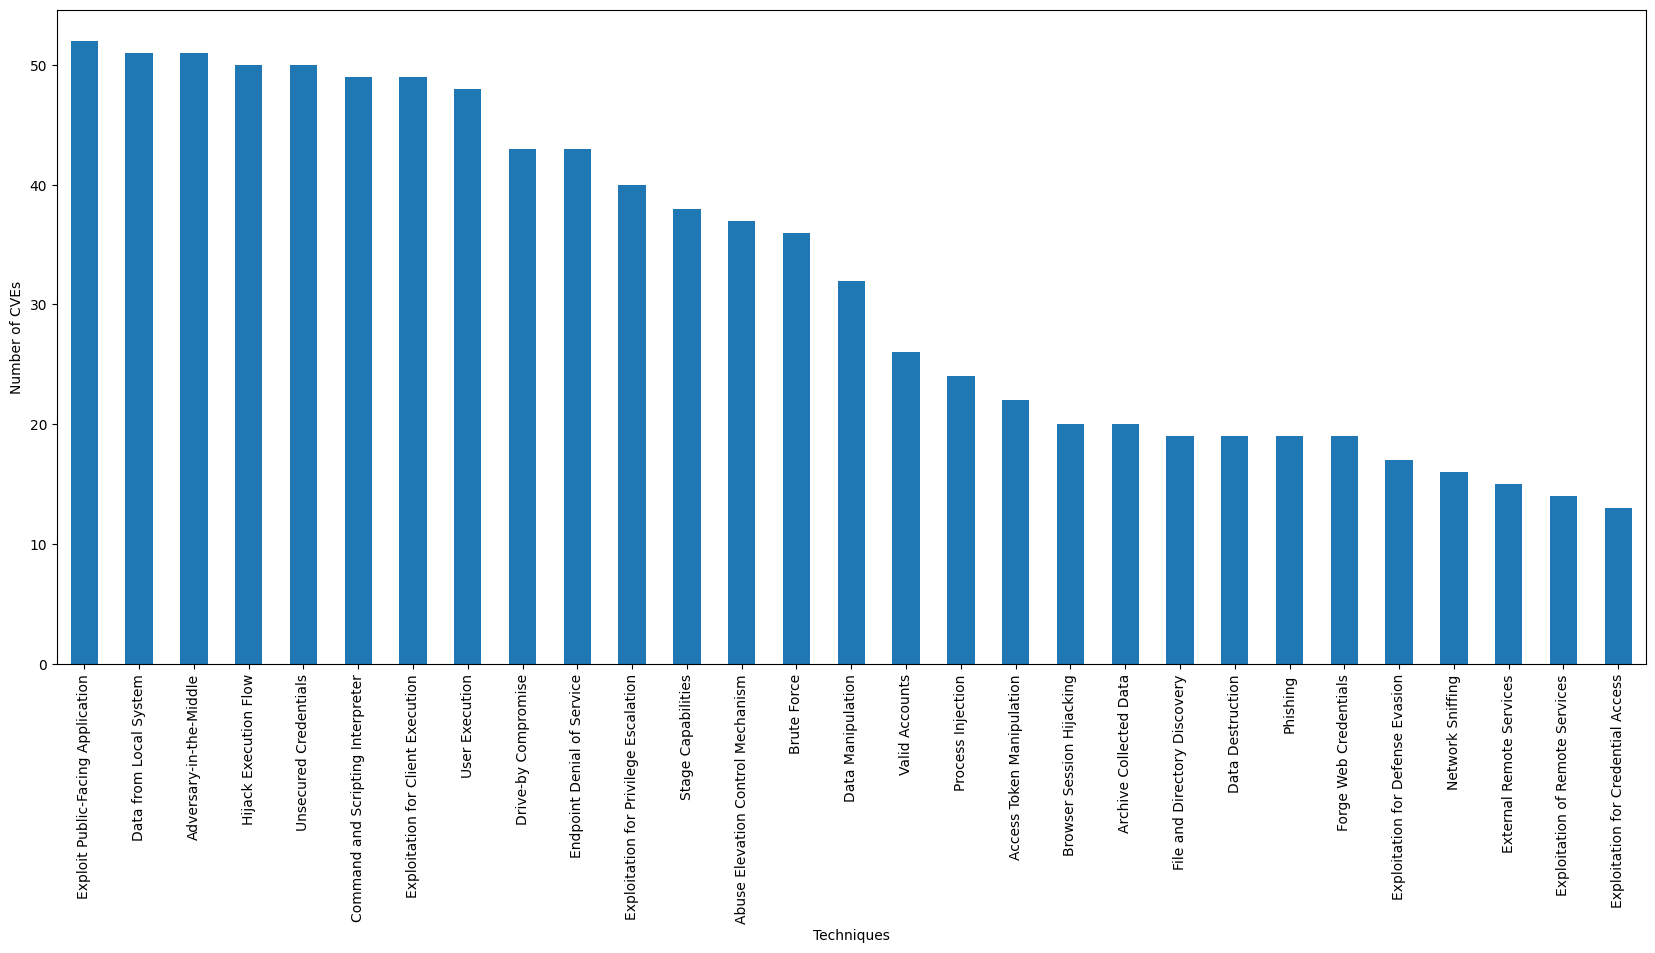

In [13]:
plot_labels_count(y_test)

In [14]:
!pip install textattack

In [15]:
import tensorflow as tf
# from textattack.augmentation import EmbeddingAugmenter
# from textattack.augmentation import WordNetAugmenter
# from textattack.augmentation import CLAREAugmenter
from textattack.augmentation import EasyDataAugmenter

2025-09-19 09:08:01.272458: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1758272881.301557     258 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1758272881.309919     258 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [16]:
def get_text_from_X_y(X_examples, y_examples):
  def f(index):
    targeted_CVE = y_examples[y_examples[index] == 1].index
    return [(X_examples.iloc[target], y_examples.iloc[target], target) for target in targeted_CVE]
  return f

def get_only_representative_text(X_train, y_train):
  nr_tech_per_CVE = y_train.apply(np.sum, axis = 1)

  def get_representative_CVE(col):
    representative_index = list(col[col == 1].index)
    representative_index = list(filter(lambda ind : nr_tech_per_CVE[ind] == 1, representative_index))
    return representative_index
  
  representative_CVE_list = y_train.apply(get_representative_CVE, axis = 0)
  def f(index):
    targeted_CVE = representative_CVE_list[index]
    return [(X_train.iloc[target], y_train.iloc[target], target) for target in targeted_CVE]
  return f

def augument_existing_data(X_train, y_train, get_base_text, skip_name=None, skip_X=None, skip_y=None):
    if skip_name is None:
        new_y_train = y_train
        new_X_train = X_train
    else:
        new_y_train = skip_y
        new_X_train = skip_X

    Y_count = y_train.apply(np.sum, axis=0)
    sorted_Y = Y_count.sort_values(ascending=False)
    max_value = None
    continue_skipping = True
    if skip_name is None:
        continue_skipping = False

    for index in sorted_Y.index:
        print(index)
        if max_value is None:
            max_value = sorted_Y[index]
        else:
            if skip_name == index:
                continue_skipping = False
            if not continue_skipping:
                new_X_train.to_csv('extended_X_train_' + index + '.csv', index=False)
                new_y_train.to_csv('extended_y_train_' + index + '.csv', index=False)
            else:
                continue

            current_value = sorted_Y[index]
            if max_value / current_value >= 2:
                targeted_CVE = get_base_text(index)

                if len(targeted_CVE) > 0:
                    multiple = int((max_value - current_value) / len(targeted_CVE))
                else:
                    multiple = 0
                    continue
                if multiple > 10:
                    multiple = 10

                aug = EasyDataAugmenter(transformations_per_example=multiple)

                for target in targeted_CVE:
                    print(target[2])
                    augumented_text_for_CVE = aug.augment(target[0]['Text'])
                    cnt = 0
                    for text in augumented_text_for_CVE:
                        # ✅ wrap dicts in DataFrame
                        new_row_X = pd.DataFrame([{
                            'Name': target[0]['Name'] + "_augumented_" + str(cnt),
                            'Text': text
                        }])
                        # handle y as DataFrame/Series/dict
                        if isinstance(target[1], dict):
                            new_row_y = pd.DataFrame([target[1]])
                        elif isinstance(target[1], pd.Series):
                            new_row_y = target[1].to_frame().T
                        else:  # already DataFrame
                            new_row_y = target[1]

                        new_X_train = pd.concat([new_X_train, new_row_X], ignore_index=True)
                        new_y_train = pd.concat([new_y_train, new_row_y], ignore_index=True)

                        cnt += 1

    return (new_X_train, new_y_train)



In [17]:
X_examples = pd.DataFrame(columns=X_train.columns)
y_examples = pd.DataFrame(columns=y_train.columns)

def parse_techniques_example(row):
    new_row_X = pd.DataFrame([{
        'Name': "example_" + str(row.name),
        'Text': row['Description']
    }])

    new_row_y = pd.DataFrame([{
        row['Technique']: 1
    }])

    global X_examples, y_examples
    X_examples = pd.concat([X_examples, new_row_X], ignore_index=True)
    y_examples = pd.concat([y_examples, new_row_y], ignore_index=True)

# after processing
y_examples.fillna(0, inplace=True)
y_examples = y_examples.astype(int)


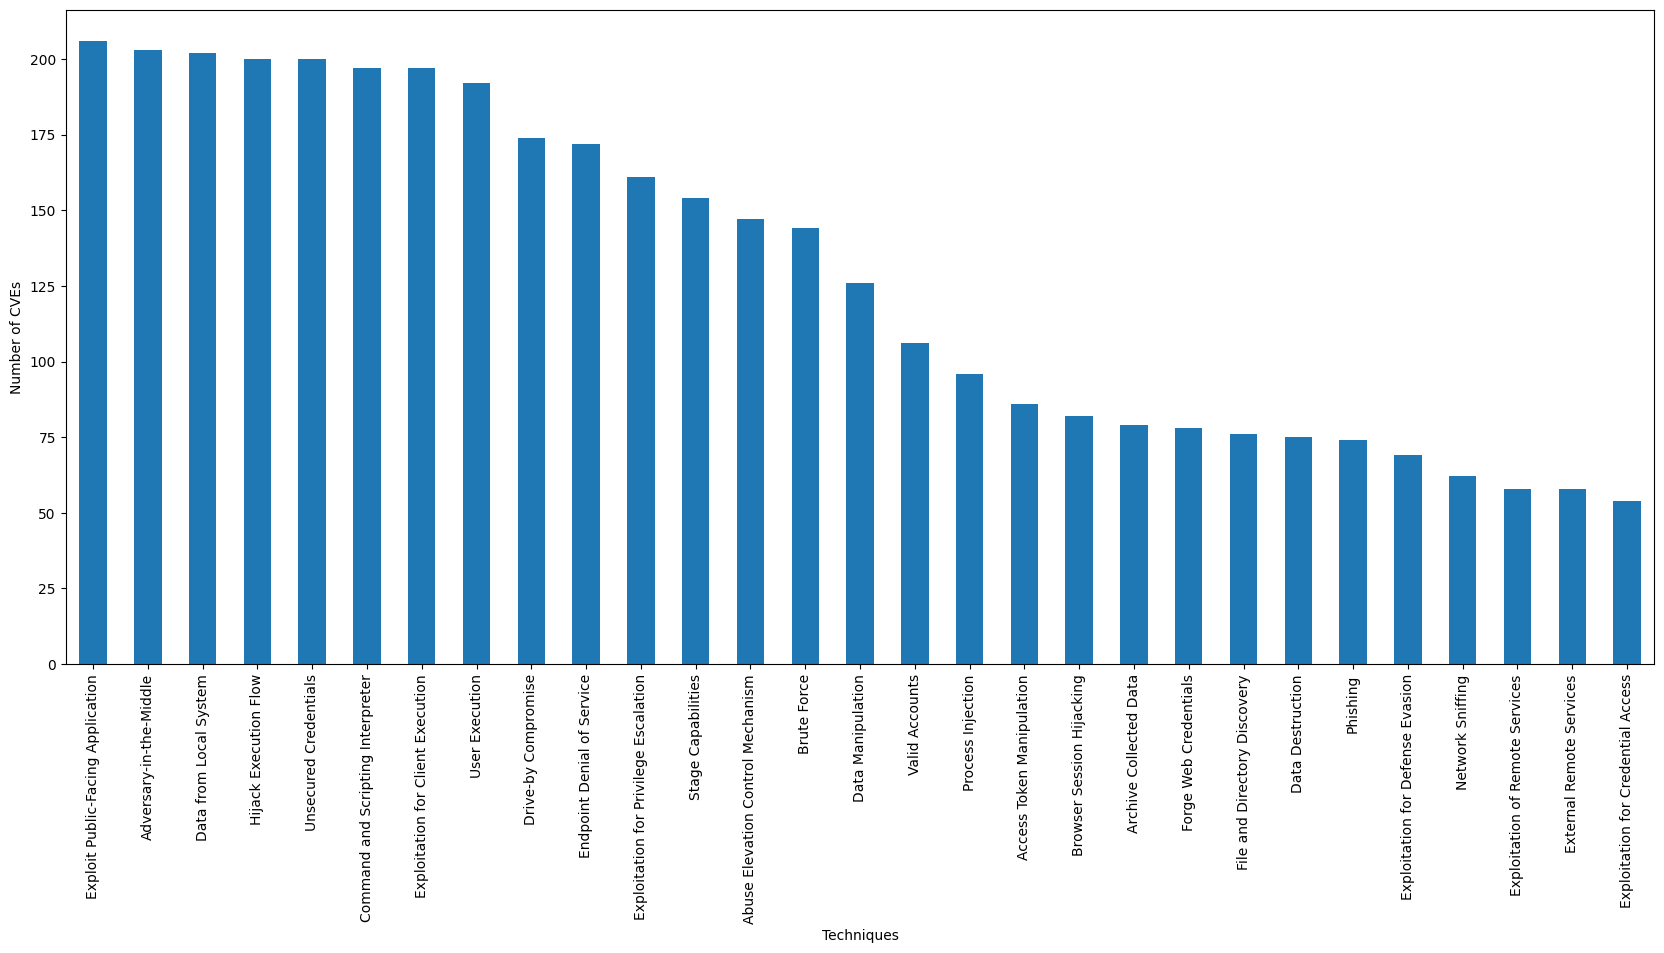

In [18]:
final_X_train = pd.concat([X_train, X_examples], ignore_index=True)
final_y_train = pd.concat([y_train, y_examples], ignore_index=True)

plot_labels_count(final_y_train)

In [19]:
(augumented_X_train, augumented_y_train) = augument_existing_data(final_X_train, final_y_train, get_text_from_X_y(X_examples, y_examples))

Exploit Public-Facing Application
Adversary-in-the-Middle
Data from Local System
Hijack Execution Flow
Unsecured Credentials
Command and Scripting Interpreter
Exploitation for Client Execution
User Execution
Drive-by Compromise
Endpoint Denial of Service
Exploitation for Privilege Escalation
Stage Capabilities
Abuse Elevation Control Mechanism
Brute Force
Data Manipulation
Valid Accounts
Process Injection
Access Token Manipulation
Browser Session Hijacking
Archive Collected Data
Forge Web Credentials
File and Directory Discovery
Data Destruction
Phishing
Exploitation for Defense Evasion
Network Sniffing
Exploitation of Remote Services
External Remote Services
Exploitation for Credential Access


In [20]:
(phising_X, phishing_y) = load_data_from_file('extended_X_train_Phishing.csv', 'extended_y_train_Phishing.csv')
(augumented_X_train, augumented_y_train) = augument_existing_data(X_train, 
                                                                  y_train, 
                                                                  get_only_representative_text(X_train, y_train),
                                                                  'Phishing',
                                                                  phising_X,
                                                                  phishing_y)

Exploit Public-Facing Application
Adversary-in-the-Middle
Data from Local System
Hijack Execution Flow
Unsecured Credentials
Command and Scripting Interpreter
Exploitation for Client Execution
User Execution
Drive-by Compromise
Endpoint Denial of Service
Exploitation for Privilege Escalation
Stage Capabilities
Abuse Elevation Control Mechanism
Brute Force
Data Manipulation
Valid Accounts
Process Injection
Access Token Manipulation
Browser Session Hijacking
Archive Collected Data
Forge Web Credentials
File and Directory Discovery
Data Destruction
Phishing


[nltk_data] Downloading package omw-1.4 to /usr/share/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


504
515
1957
1958
1959
1960
1961
1962
1963
1964
1965
1966
1967
1968
1969
1970
1971
1972
1973
1974
1975
1976
1977
1978
1979
1980
1981
1982
1983
1984
1985
1986
1987
1988
1989
1990
1991
1992
1993
1994
1995
1996
1997
Exploitation for Defense Evasion
14


[nltk_data] Downloading package omw-1.4 to /usr/share/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


733
734
2364
2365
2366
2367
2368
2369
2370
2371
2372
2373
2374
2375
2376
2377
2378
2379
2380
2381
2382
2383
2384
2385
2386
2387
2388
2389
2390
2391
2392
2393
2394
2395
2396
2397
2398
2399
2400
2401
2402
2403
2404
2405
2406
2407
2408
2409
2410
2411
2412
Network Sniffing
92


...

730
966
2413
2414
2415
2416
2417
2418
2419
2420
2421
2422
2423
2424
2425
2426
2427
2428
2429
2430
2431
2432
2433
2434
2435
2436
2437
2438
2439
2440
2441
2442
2443
2444
2445
2446
2447
2448
2449
2450
2451
2452
2453
External Remote Services
554


[nltk_data] Downloading package omw-1.4 to /usr/share/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


1998
1999
2000
2001
2002
2003
2004
2005
2006
2007
2008
2009
2010
2011
2012
2013
2014
2015
2016
2017
2018
2019
2020
2021
2022
2023
Exploitation for Credential Access
15


[nltk_data] Downloading package omw-1.4 to /usr/share/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


736
961
2781
2782
2783
2784
2785
2786
2787
2788
2789
2790
2791
2792
2793
2794
2795
2796
2797
2798
2799
2800
2801
2802
2803
2804
2805
2806
2807
2808
2809
2810
2811
2812
2813
2814
2815
2816
2817
2818
2819


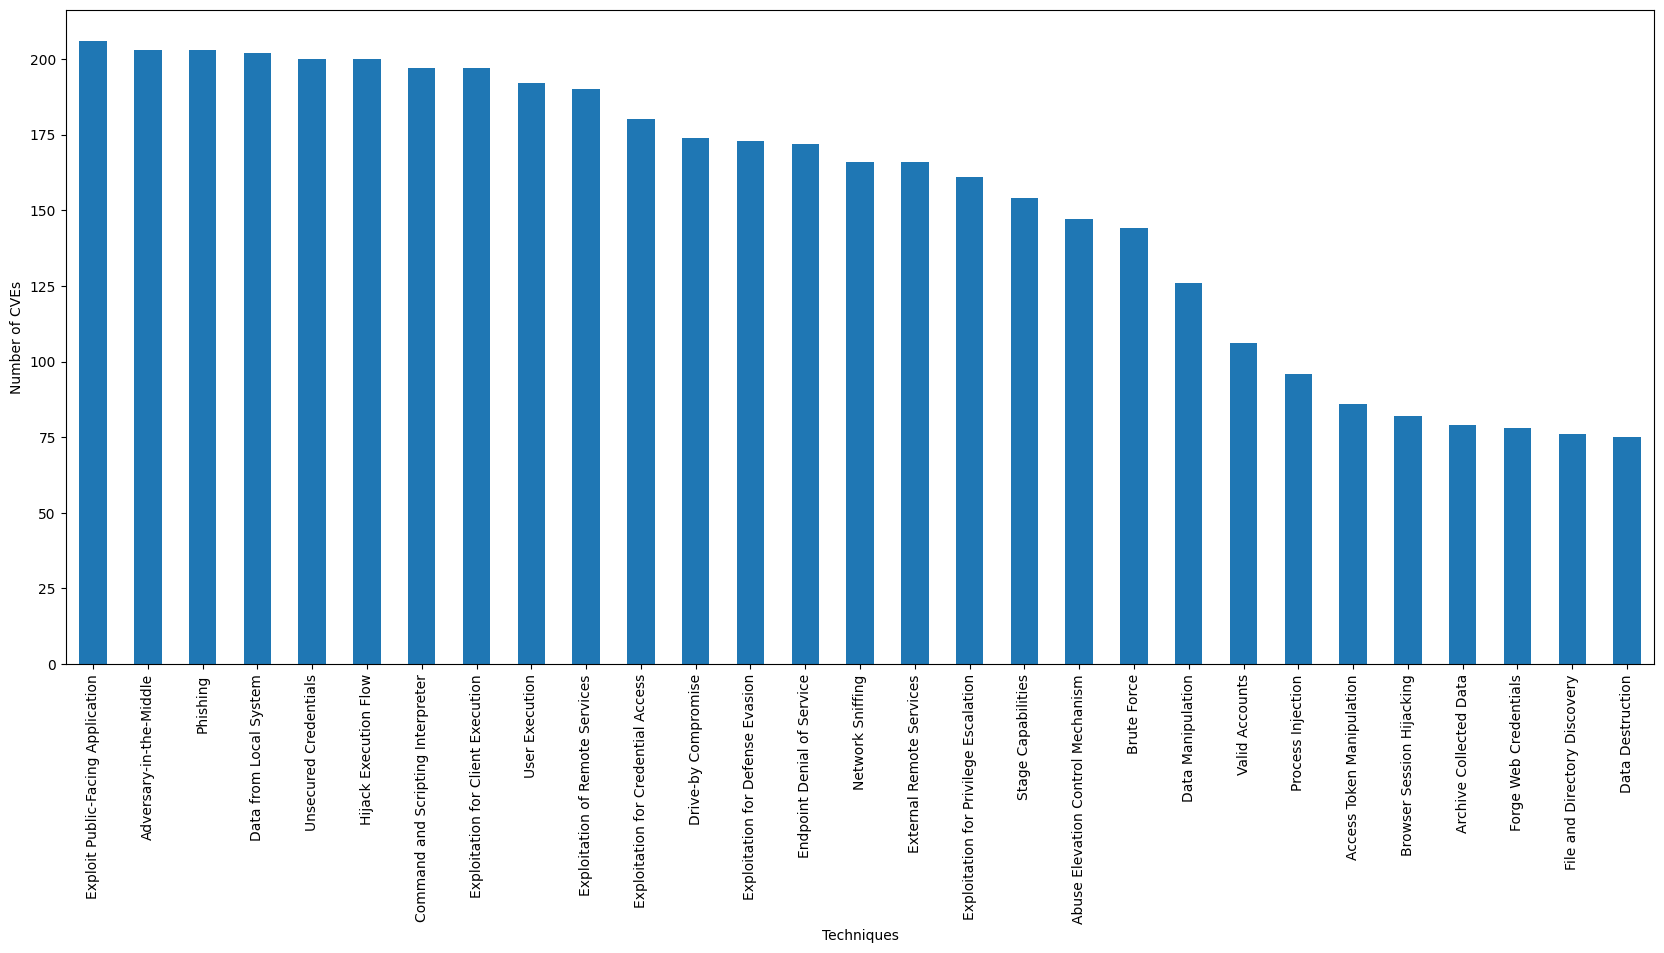

In [21]:
plot_labels_count(augumented_y_train)

In [22]:
augumented_X_train.to_csv('final_extended_X_train.csv', index=False)
augumented_y_train.to_csv('final_extended_y_train.csv', index=False)

## Auxiliary functions

In [23]:
# pip install spacy
!python -m spacy download en_core_web_sm


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 46.2 MB/s eta 0:00:0000:0100:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [24]:
import spacy

# Load the English language model
nlp = spacy.load("en_core_web_sm")


def text_processing(text):
  doc = nlp(text)
  # Extract tokens for the given doc
  tokens = [token.lemma_ for token in doc if not (token.is_punct or token.is_space or token.is_stop) and token.is_alpha ]
  return tokens

def text_processing_keep_nouns_verbs(text):
  doc = nlp(text)
  # Extract tokens for the given doc
  tokens = [token.lemma_ for token in doc if not (token.is_punct or token.is_space or token.is_stop) and (token.pos_=='NOUN' or token.pos_=='VERB')]
  return tokens

def compute_metrics(predicted_y, true_y, metric_function, columns, limit):
  results = pd.DataFrame(columns = columns)
  results.loc[len(results)] = metric_function(true_y, predicted_y, average=None)
  sorted_results = results.sort_values(by=0, axis=1, ascending=False)
  return sorted_results.iloc[:, :limit]


def print_confusion_matrix(cf_matrix):
  ax = sns.heatmap(cf_matrix, annot=True, cmap='Blues')

  ax.set_title('Seaborn Confusion Matrix with labels\n\n');
  ax.set_xlabel('\nPredicted Values')
  ax.set_ylabel('Actual Values ');

  ## Ticket labels - List must be in alphabetical order
  ax.xaxis.set_ticklabels(['False','True'])
  ax.yaxis.set_ticklabels(['False','True'])

  ## Display the visualization of the Confusion Matrix.
  plt.show()


def print_F1_based_on_distribution(y_true, y_pred, Y, columns):
  fig,ax = plt.subplots()

  results = pd.DataFrame(columns = columns)
  results.loc[len(results)] = f1_score(y_true, y_pred, average=None)
  
  Y_count = Y.apply(np.sum, axis=0)
  Y_count_sorted = Y_count.sort_values(ascending=False)
  
  ax.bar(Y_count_sorted.index, Y_count_sorted.values)
  ax.set_xlabel("Techniques")
  ax.set_ylabel("Number of CVEs")
  plt.xticks(rotation=90)

  ax2=ax.twinx()
  ax2.plot(Y_count_sorted.index, results[Y_count_sorted.index].iloc[0], color='red')
  ax2.set_ylabel("F1 Score")

  ax = plt.gca()
  plt.show()



def plot_grid_search(cv_results, name_param_1, name_param_2, score_m, limit=None):
    results_df = pd.DataFrame(cv_results)
    results_df = results_df.assign(
        param1=results_df["params"].apply(lambda x: x[name_param_1])
    )
    results_df = results_df.assign(
        param2=results_df["params"].apply(lambda x: x[name_param_2])
    )
    plot = sns.lineplot(data=results_df, x="param1", y=score_m, hue="param2")
    plot.set(xlabel=name_param_1, ylabel=score_m)
    plot.legend(title=name_param_2)
    if limit is not None:
      plot.set_xlim(left=0, right=limit)

In [25]:
pip install scikit-multilearn


Note: you may need to restart the kernel to use updated packages.


In [26]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfTransformer
from skmultilearn.problem_transform import LabelPowerset
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline


text_clf = Pipeline([
                     ('vect', CountVectorizer(tokenizer=text_processing,
                       
                       lowercase = True,
                       max_df = 0.7,
                       min_df = 10)),
                     ('tfidf', TfidfTransformer()),
                     ('clf', LabelPowerset(classifier=MultinomialNB())),
])

text_clf.fit(X_train['Text'], y_train.values)
prediction = text_clf.predict(X_test['Text'])

/usr/local/lib/python3.11/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


In [27]:
from sklearn.metrics import f1_score, accuracy_score, recall_score, precision_score
print(accuracy_score(y_test.values, prediction))

0.6218836565096952


In [28]:
print("F1 Score")
compute_metrics(prediction, y_test.values, f1_score, y_test.columns, 31)

F1 Score


,Brute Force,Network Sniffing,Abuse Elevation Control Mechanism,Phishing,Exploitation of Remote Services,Forge Web Credentials,Archive Collected Data,Process Injection,Hijack Execution Flow,Data Destruction,...,External Remote Services,Data Manipulation,Endpoint Denial of Service,File and Directory Discovery,Exploitation for Credential Access,Exploit Public-Facing Application,Exploitation for Client Execution,Command and Scripting Interpreter,Exploitation for Privilege Escalation,Valid Accounts
0,0.90411,0.875,0.815789,0.8125,0.8,0.8,0.787879,0.736842,0.733945,0.733333,...,0.5,0.5,0.448276,0.272727,0.266667,0.137931,0.04,0.04,0.0,0.0


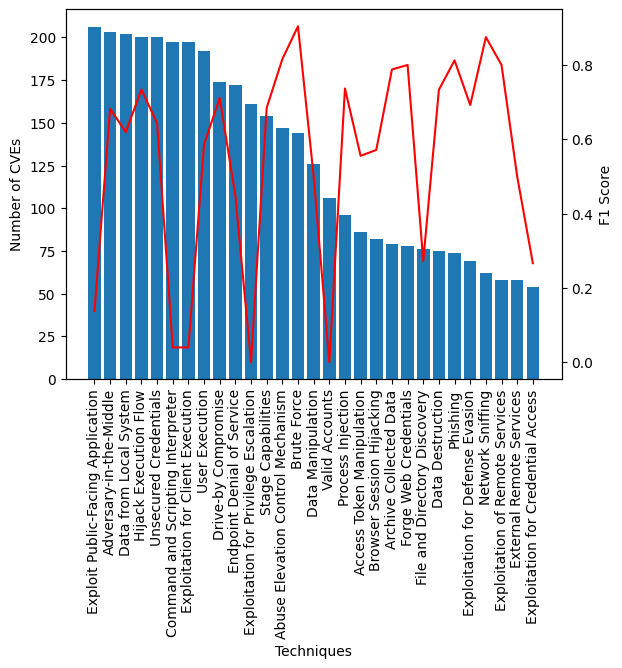

In [29]:
print_F1_based_on_distribution(y_test.values, prediction, y_train,  y_test.columns)

In [30]:
print("Precision Score")
compute_metrics(prediction, y_test.values, precision_score, y_test.columns, 31)

Precision Score


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


,Process Injection,Exploitation for Client Execution,External Remote Services,Exploitation for Defense Evasion,File and Directory Discovery,Command and Scripting Interpreter,Phishing,Archive Collected Data,Data Destruction,Browser Session Hijacking,...,Drive-by Compromise,Hijack Execution Flow,Exploit Public-Facing Application,Adversary-in-the-Middle,Data from Local System,Stage Capabilities,User Execution,Unsecured Credentials,Exploitation for Privilege Escalation,Valid Accounts
0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,0.680851,0.677966,0.666667,0.573333,0.564516,0.520548,0.5,0.494624,0.0,0.0


In [31]:
print("Recall Score")
compute_metrics(prediction, y_test.values, recall_score, y_test.columns, 31)

Recall Score


,Stage Capabilities,Unsecured Credentials,Brute Force,Network Sniffing,Adversary-in-the-Middle,Abuse Elevation Control Mechanism,Hijack Execution Flow,Drive-by Compromise,Forge Web Credentials,Exploitation of Remote Services,...,Data Manipulation,External Remote Services,Endpoint Denial of Service,File and Directory Discovery,Exploitation for Credential Access,Exploit Public-Facing Application,Command and Scripting Interpreter,Exploitation for Client Execution,Exploitation for Privilege Escalation,Valid Accounts
0,1.0,0.92,0.916667,0.875,0.843137,0.837838,0.8,0.744186,0.736842,0.714286,...,0.34375,0.333333,0.302326,0.157895,0.153846,0.076923,0.020408,0.020408,0.0,0.0


In [32]:
print(f1_score(y_test.values, prediction, average='weighted'))

0.519187565823645


In [33]:
print(precision_score(y_test.values, prediction, average='weighted'))

0.7248592465130564


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [34]:
print(recall_score(y_test.values, prediction, average='weighted'))

0.5236051502145923


In [35]:
from sklearn.metrics import multilabel_confusion_matrix
conf_matrix = multilabel_confusion_matrix(y_test.values, prediction)

Process Injection


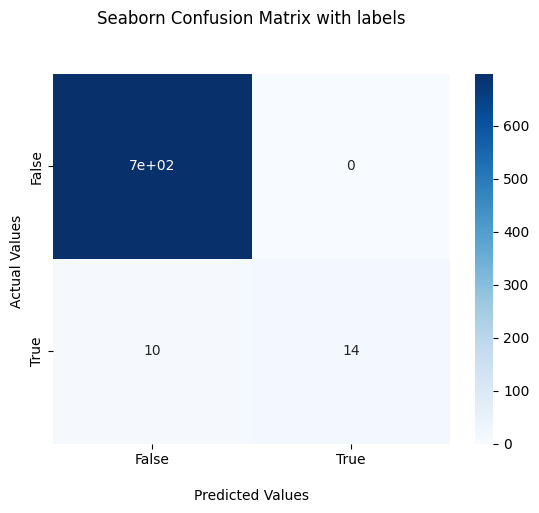

In [36]:
print(y_test.columns[0])
print_confusion_matrix(conf_matrix[0])

Access Token Manipulation


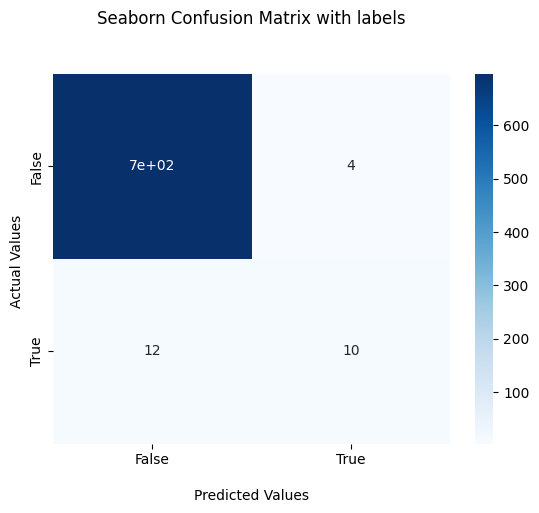

In [37]:
print(y_test.columns[1])
print_confusion_matrix(conf_matrix[1])

Hijack Execution Flow


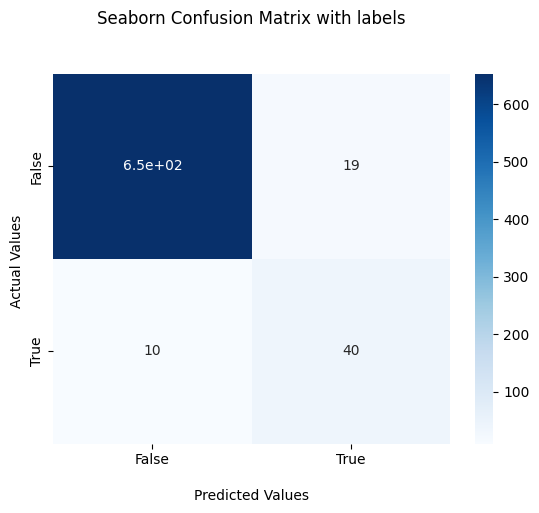

In [38]:
print(y_test.columns[2])
print_confusion_matrix(conf_matrix[2])

Data from Local System


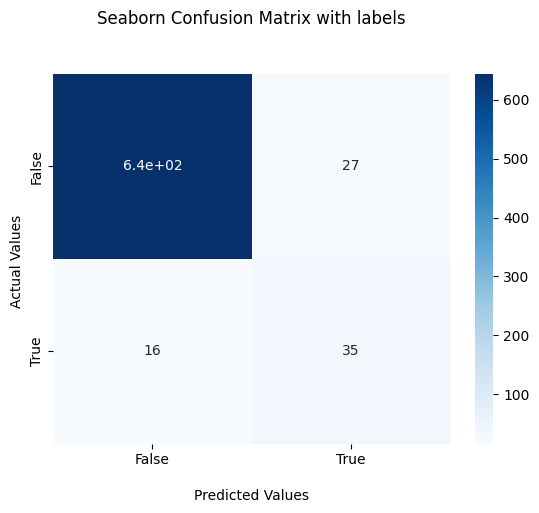

In [39]:
print(y_test.columns[3])
print_confusion_matrix(conf_matrix[3])

External Remote Services


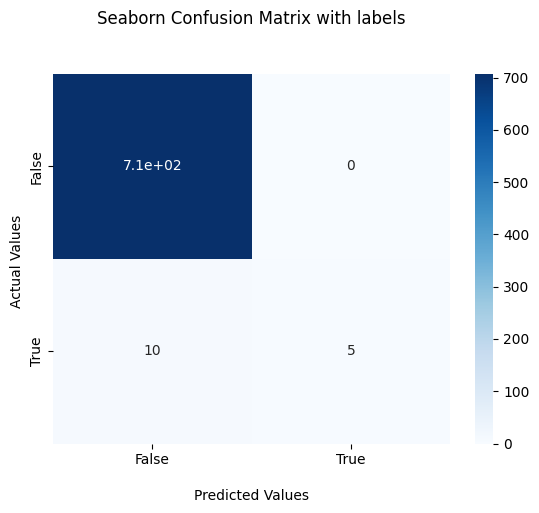

In [40]:
print(y_test.columns[4])
print_confusion_matrix(conf_matrix[4])

Data Manipulation


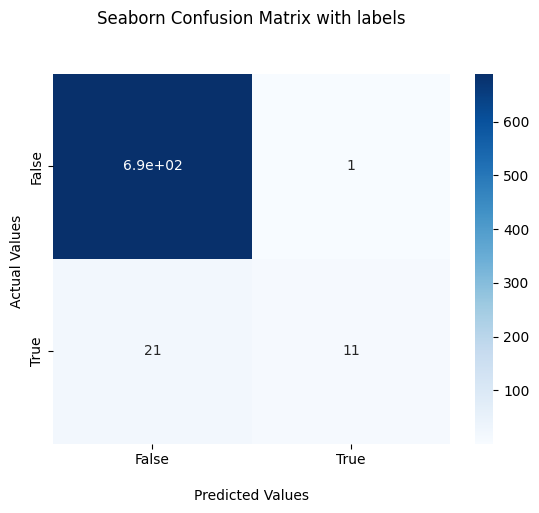

In [41]:
print(y_test.columns[5])
print_confusion_matrix(conf_matrix[5])

Network Sniffing


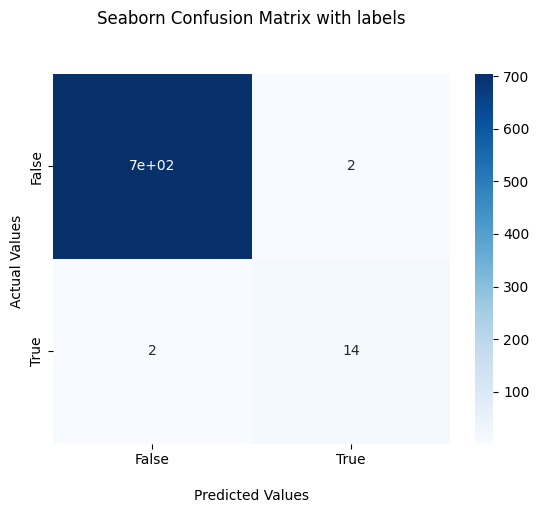

In [42]:
print(y_test.columns[6])
print_confusion_matrix(conf_matrix[6])

Exploitation for Privilege Escalation


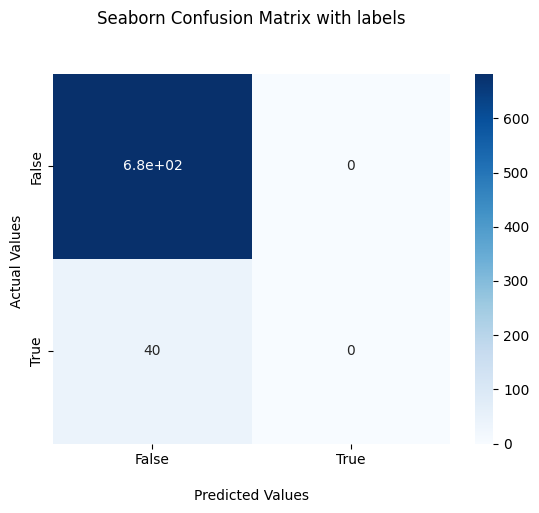

In [43]:
print(y_test.columns[7])
print_confusion_matrix(conf_matrix[7])

Phishing


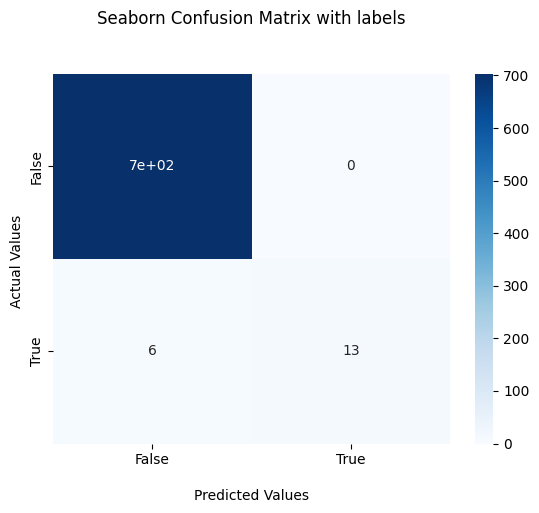

In [44]:
i = 9
print(y_test.columns[i])
print_confusion_matrix(conf_matrix[i])

Archive Collected Data


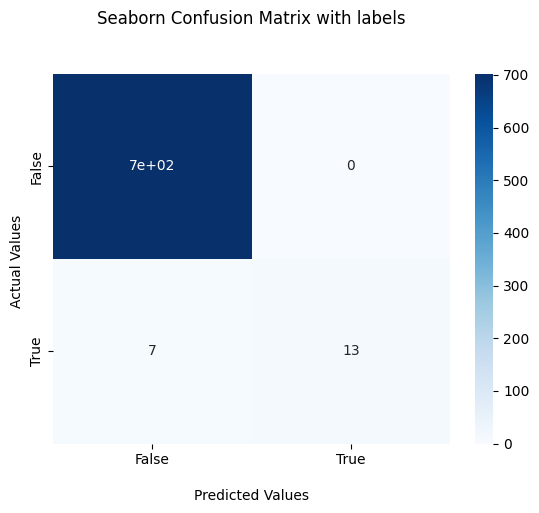

In [45]:
i = 10
print(y_test.columns[i])
print_confusion_matrix(conf_matrix[i])

Data Destruction


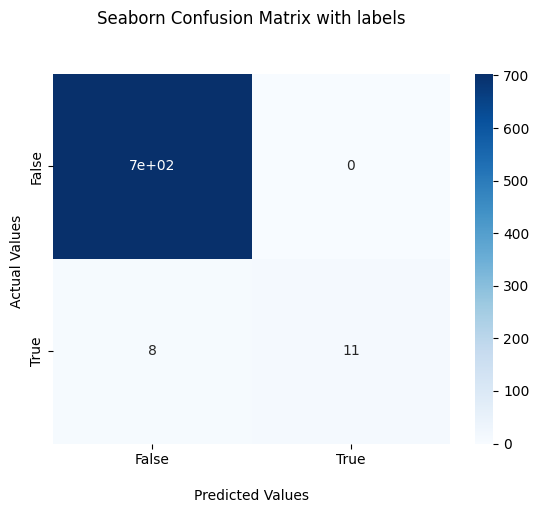

In [46]:
i = 11
print(y_test.columns[i])
print_confusion_matrix(conf_matrix[i])

Browser Session Hijacking


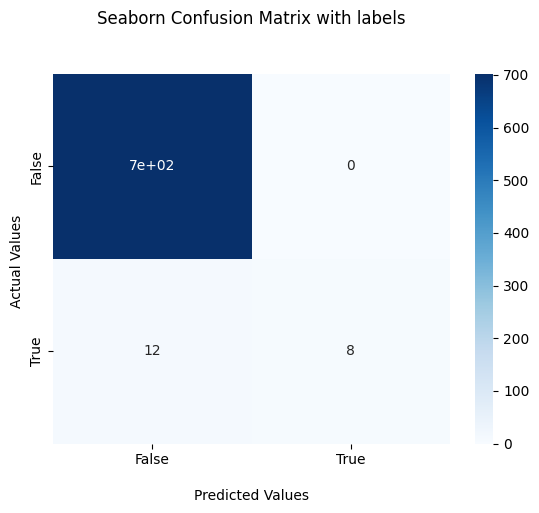

In [47]:
i = 12
print(y_test.columns[i])
print_confusion_matrix(conf_matrix[i])

Exploitation for Credential Access


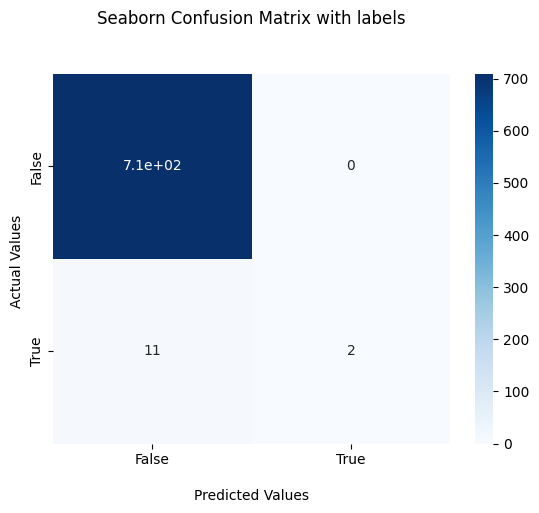

In [48]:
i = 13
print(y_test.columns[i])
print_confusion_matrix(conf_matrix[i])

Abuse Elevation Control Mechanism


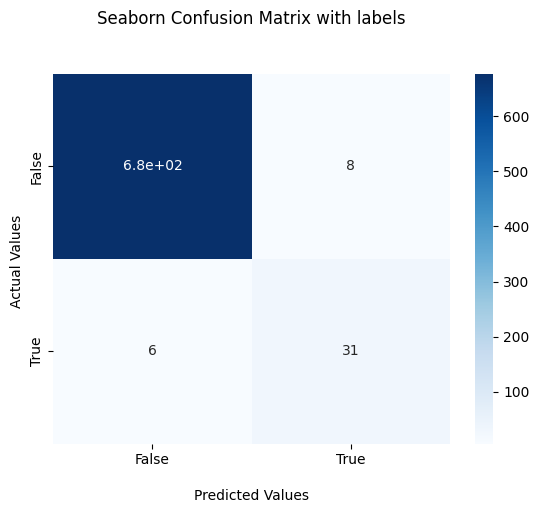

In [49]:
i = 14
print(y_test.columns[i])
print_confusion_matrix(conf_matrix[i])

## Naive Bayes OneVsRestClassifier 
Normal

In [50]:
from sklearn.multiclass import OneVsRestClassifier

text_clf = Pipeline([
                     ('vect', CountVectorizer(tokenizer=text_processing,
                       
                       lowercase = True,
                       max_df = 0.7,
                       min_df = 10)),
                     ('tfidf', TfidfTransformer()),
                     ('clf', OneVsRestClassifier(MultinomialNB())),
])

text_clf.fit(X_train['Text'], y_train.values)
prediction = text_clf.predict(X_test['Text'])

/usr/local/lib/python3.11/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


In [51]:
print(accuracy_score(y_test.values, prediction))

0.19806094182825484


In [52]:
print("F1 Score")
compute_metrics(prediction, y_test.values, f1_score, y_test.columns, 31)

F1 Score


,Brute Force,Adversary-in-the-Middle,Stage Capabilities,Drive-by Compromise,Data Destruction,Hijack Execution Flow,Unsecured Credentials,Exploitation for Credential Access,Exploitation for Defense Evasion,Abuse Elevation Control Mechanism,...,File and Directory Discovery,Archive Collected Data,User Execution,Command and Scripting Interpreter,Exploit Public-Facing Application,Exploitation for Privilege Escalation,External Remote Services,Exploitation for Client Execution,Exploitation of Remote Services,Valid Accounts
0,0.779661,0.675325,0.631579,0.575758,0.538462,0.412698,0.333333,0.266667,0.210526,0.195122,...,0.1,0.095238,0.040816,0.04,0.037037,0.0,0.0,0.0,0.0,0.0


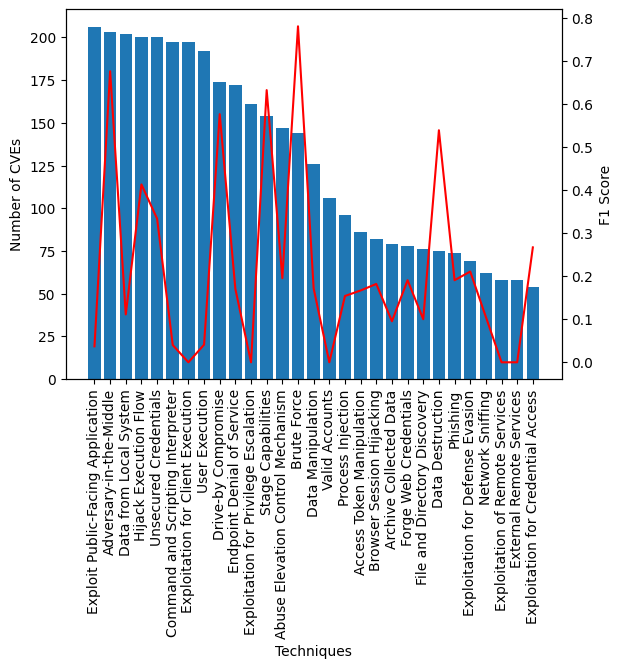

In [53]:
print_F1_based_on_distribution(y_test.values, prediction, y_train,  y_test.columns)

In [54]:
print("Precision Score")
compute_metrics(prediction, y_test.values, precision_score, y_test.columns, 31)

Precision Score


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


,Process Injection,Browser Session Hijacking,Endpoint Denial of Service,Exploitation for Defense Evasion,File and Directory Discovery,Brute Force,Unsecured Credentials,User Execution,Adversary-in-the-Middle,Access Token Manipulation,...,Phishing,Stage Capabilities,Drive-by Compromise,Exploit Public-Facing Application,Network Sniffing,External Remote Services,Exploitation for Privilege Escalation,Exploitation for Client Execution,Exploitation of Remote Services,Valid Accounts
0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,0.947368,0.826087,0.5,0.333333,0.0,0.0,0.0,0.0,0.0


In [55]:
print("Recall Score")
compute_metrics(prediction, y_test.values, recall_score, y_test.columns, 31)

Recall Score


,Brute Force,Adversary-in-the-Middle,Stage Capabilities,Drive-by Compromise,Data Destruction,Hijack Execution Flow,Unsecured Credentials,Exploitation for Credential Access,Exploitation for Defense Evasion,Abuse Elevation Control Mechanism,...,File and Directory Discovery,Archive Collected Data,User Execution,Command and Scripting Interpreter,Exploit Public-Facing Application,Exploitation for Privilege Escalation,External Remote Services,Exploitation for Client Execution,Exploitation of Remote Services,Valid Accounts
0,0.638889,0.509804,0.473684,0.44186,0.368421,0.26,0.2,0.153846,0.117647,0.108108,...,0.052632,0.05,0.020833,0.020408,0.019231,0.0,0.0,0.0,0.0,0.0


In [56]:
print(f1_score(y_test.values, prediction, average='weighted'))

print(recall_score(y_test.values, prediction, average='weighted'))

print(precision_score(y_test.values, prediction, average='weighted'))

conf_matrix = multilabel_confusion_matrix(y_test.values, prediction)

0.23723547073425674
0.1609442060085837
0.7959818374074765


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


## Naive Bayes Binary Relevance
Normal

In [57]:
from skmultilearn.problem_transform import BinaryRelevance
text_clf = Pipeline([
                     ('vect', CountVectorizer(tokenizer=text_processing,
                       lowercase = True,
                       max_df = 0.7,
                       min_df = 10)),
                     ('tfidf', TfidfTransformer()),
                     ('clf', BinaryRelevance(classifier=MultinomialNB())),
])

text_clf.fit(X_train['Text'], y_train.values)
prediction = text_clf.predict(X_test['Text'])

/usr/local/lib/python3.11/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


0.19806094182825484
F1 Score
Precision Score
Recall Score
0.23723547073425674
0.1609442060085837
0.7959818374074765


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


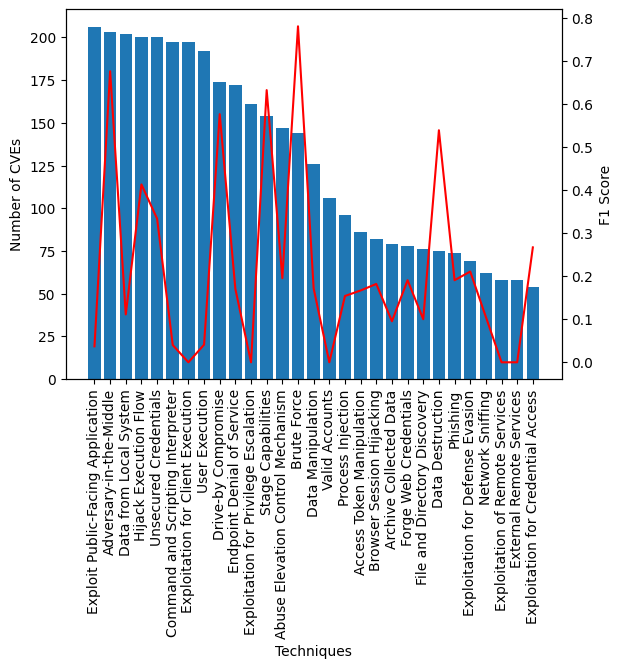

In [58]:
print(accuracy_score(y_test.values, prediction))
print("F1 Score")
compute_metrics(prediction, y_test.values, f1_score, y_test.columns, 31)
print("Precision Score")
compute_metrics(prediction, y_test.values, precision_score, y_test.columns, 31)
print("Recall Score")
compute_metrics(prediction, y_test.values, recall_score, y_test.columns, 31)
print(f1_score(y_test.values, prediction, average='weighted'))
print(recall_score(y_test.values, prediction, average='weighted'))
print(precision_score(y_test.values, prediction, average='weighted'))
conf_matrix = multilabel_confusion_matrix(y_test.values, prediction)

print_F1_based_on_distribution(y_test.values, prediction, y_train,  y_test.columns)


## Naive Bayes Classifier Chain


In [59]:
from skmultilearn.problem_transform import ClassifierChain

text_clf = Pipeline([
                     ('vect', CountVectorizer(tokenizer=text_processing,
                       
                       lowercase = True,
                       max_df = 0.7,
                       min_df = 10)),
                     ('tfidf', TfidfTransformer()),
                     ('clf', ClassifierChain(classifier=MultinomialNB())),
])

text_clf.fit(X_train['Text'], y_train.values)
prediction = text_clf.predict(X_test['Text'])

/usr/local/lib/python3.11/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


0.26454293628808867
F1 Score


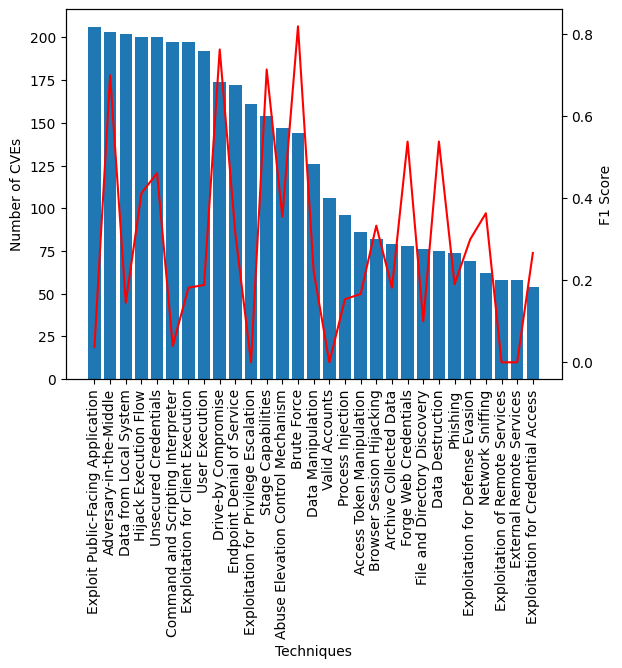

In [60]:
print(accuracy_score(y_test.values, prediction))
print("F1 Score")
compute_metrics(prediction, y_test.values, f1_score, y_test.columns, 31)
print_F1_based_on_distribution(y_test.values, prediction, y_train,  y_test.columns)

In [61]:
print("Precision Score")
compute_metrics(prediction, y_test.values, precision_score, y_test.columns, 31)

Precision Score


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


,Process Injection,Browser Session Hijacking,Exploit Public-Facing Application,Endpoint Denial of Service,Exploitation for Defense Evasion,File and Directory Discovery,Brute Force,Unsecured Credentials,User Execution,Access Token Manipulation,...,Phishing,Adversary-in-the-Middle,Drive-by Compromise,Exploitation for Client Execution,Stage Capabilities,Network Sniffing,Exploitation for Privilege Escalation,External Remote Services,Exploitation of Remote Services,Valid Accounts
0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,0.965517,0.878788,0.833333,0.78125,0.666667,0.0,0.0,0.0,0.0


In [62]:
print("Recall Score")
compute_metrics(prediction, y_test.values, recall_score, y_test.columns, 31)

Recall Score


,Brute Force,Drive-by Compromise,Stage Capabilities,Adversary-in-the-Middle,Forge Web Credentials,Data Destruction,Unsecured Credentials,Hijack Execution Flow,Network Sniffing,Abuse Elevation Control Mechanism,...,Access Token Manipulation,Process Injection,Data from Local System,File and Directory Discovery,Command and Scripting Interpreter,Exploit Public-Facing Application,Valid Accounts,Exploitation for Privilege Escalation,External Remote Services,Exploitation of Remote Services
0,0.694444,0.674419,0.657895,0.54902,0.368421,0.368421,0.3,0.26,0.25,0.216216,...,0.090909,0.083333,0.078431,0.052632,0.020408,0.019231,0.0,0.0,0.0,0.0


In [63]:
print(f1_score(y_test.values, prediction, average='weighted'))

0.3111256756159172


In [64]:
print(precision_score(y_test.values, prediction, average='weighted'))

0.8671853627663344


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [65]:
print(recall_score(y_test.values, prediction, average='weighted'))

0.22210300429184548


In [66]:
conf_matrix = multilabel_confusion_matrix(y_test.values, prediction)

# CNN + Word2Vec


In [67]:
import spacy
nlp = spacy.load('en_core_web_sm')

In [68]:
# Need to resolve the dependecy conflict here. 
!pip install -U scikit-learn
!pip install tensorflow-addons

In [69]:
X_train = pd.read_csv('/kaggle/input/inputfile/X_train.csv')
y_train = pd.read_csv('/kaggle/input/inputfile/y_train.csv')

X_train_extended = pd.read_csv('/kaggle/input/inputfile/final_extended_X_train.csv')
y_train_extended = pd.read_csv('/kaggle/input/inputfile/final_extended_y_train.csv')

X_test = pd.read_csv('/kaggle/input/inputfile/X_test.csv')
y_test = pd.read_csv('/kaggle/input/inputfile/y_test.csv')

pd.set_option('display.max_colwidth', None)


In [70]:
import re,string

def strip_links(text):
    link_regex    = re.compile('((https?):((//)|(\\\\))+([\w\d:#@%/;$()~_?\+-=\\\.&](#!)?)*)', re.DOTALL)
    links         = re.findall(link_regex, text)
    for link in links:
        text = text.replace(link[0], ', ')    
    return text

In [71]:
X_train['Text']=X_train['Text'].apply(lambda x:strip_links(x))
X_train_extended['Text']=X_train_extended['Text'].apply(lambda x:strip_links(x))
X_test['Text']=X_test['Text'].apply(lambda x:strip_links(x))

In [72]:
X_train['Text']=X_train['Text'].str.replace("\n",' ')
X_train_extended['Text']=X_train_extended['Text'].str.replace("\n",' ')
X_test['Text']=X_test['Text'].str.replace("\n",' ')

In [73]:
def remove_punctuations(text):
    for punctuation in string.punctuation:
        text = text.replace(punctuation, '')
    return text

# Apply to the DF series
X_train['Text'] = X_train['Text'].apply(remove_punctuations)
X_train_extended['Text'] = X_train_extended['Text'].apply(remove_punctuations)
X_test['Text'] = X_test['Text'].apply(remove_punctuations)

text_lines = list()
lines = X_train['Text'].values.tolist()

for line in lines:
    doc = nlp(line)
    tokens = [token.lemma_ for token in doc if not (token.is_punct or token.is_space or token.is_stop) and token.is_alpha]

    text_lines.append(tokens)


text_lines_extended = list()
lines_extended = X_train_extended['Text'].values.tolist()

for line in lines_extended:
    doc = nlp(line)
    tokens = [token.lemma_ for token in doc if not (token.is_punct or token.is_space or token.is_stop) and token.is_alpha]

    text_lines_extended.append(tokens)


In [74]:
print(X_train['Text'].apply(lambda x:len(str(x).split())).max())
print(X_train_extended['Text'].apply(lambda x:len(str(x).split())).max())

522
522


In [75]:
max_features = 5000
maxlen = 500

In [76]:
token=tf.keras.preprocessing.text.Tokenizer(num_words=max_features)
token.fit_on_texts(text_lines)

token_extended=tf.keras.preprocessing.text.Tokenizer(num_words=max_features)
token_extended.fit_on_texts(text_lines_extended)

In [77]:
X_train_seq=token.texts_to_sequences(X_train['Text'])
X_train__extended_seq=token.texts_to_sequences(X_train_extended['Text'])

X_test_seq=token.texts_to_sequences(X_test['Text'])

In [78]:
!pip install keras
!pip install keras-preprocessing


In [79]:
from keras_preprocessing.sequence import pad_sequences
X_train_pad = pad_sequences(X_train_seq, maxlen=maxlen)
X_train__extended_pad = pad_sequences(X_train__extended_seq, maxlen=maxlen)

X_test_pad = pad_sequences(X_test_seq, maxlen=maxlen)

In [80]:
word_index = token.word_index
word_extended_index = token_extended.word_index

In [81]:
print(len(token.word_index))
print(len(token_extended.word_index))




4743
6355


In [82]:
from gensim.models import Word2Vec, KeyedVectors
# Load pretrained Glove model (in word2vec form)
word2vec_model = KeyedVectors.load_word2vec_format("/kaggle/input/inputfile/vulner_embedding.bin", binary=True)
word2vec_extended_model = KeyedVectors.load_word2vec_format("/kaggle/input/inputfile/vulner_embedding.bin", binary=True)

In [83]:
embedding_vector_length = 150

In [84]:
embedding_matrix = np.zeros((max_features + 1, embedding_vector_length))
embedding_extended_matrix = np.zeros((max_features + 1, embedding_vector_length))

print(embedding_matrix.shape)

(5001, 150)


In [85]:
for word, i in sorted(token.word_index.items(),key=lambda x:x[1]):
    if i >= (max_features+1):
        break
    if word in word2vec_model:
        embedding_vector = word2vec_model[word]
    embedding_matrix[i] = embedding_vector
    
for word, i in sorted(token_extended.word_index.items(),key=lambda x:x[1]):
    if i >= (max_features+1):
        break
    if word in word2vec_extended_model:
        embedding_extended_vector = word2vec_extended_model[word]
    embedding_extended_matrix[i] = embedding_extended_vector
    

## Auxiliary Functions

In [86]:
import keras.backend as K

def round_prediction(prediction):
  rounded = []
  for line in prediction:
    new_line = np.round(line)
    rounded.append(new_line)
  return rounded

def compute_metrics(predicted_y, true_y, metric_function, columns, limit):
  results = pd.DataFrame(columns = columns)
  results.loc[len(results)] = metric_function(true_y, predicted_y, average=None)
  sorted_results = results.sort_values(by=0, axis=1, ascending=False)
  return sorted_results.iloc[:, :limit]

def print_confusion_matrix(cf_matrix, name):
  ax = sns.heatmap(cf_matrix, annot=True, cmap='Blues')

  ax.set_title(name + ' Confusion Matrix \n\n');
  ax.set_xlabel('\nPredicted Values')
  ax.set_ylabel('Actual Values ');

  ## Ticket labels - List must be in alphabetical order
  ax.xaxis.set_ticklabels(['False','True'])
  ax.yaxis.set_ticklabels(['False','True'])

  ## Display the visualization of the Confusion Matrix.
  plt.show()

def print_F1_based_on_distribution(y_true, y_pred, Y, columns):
  fig,ax = plt.subplots()

  results = pd.DataFrame(columns = columns)
  results.loc[len(results)] = f1_score(y_true, y_pred, average=None)
  
  Y_count = Y.apply(np.sum, axis=0)
  Y_count_sorted = Y_count.sort_values(ascending=False)
  
  ax.bar(Y_count_sorted.index, Y_count_sorted.values)
  ax.set_xlabel("Techniques")
  ax.set_ylabel("Number of CVEs")
  plt.xticks(rotation=90)

  ax2=ax.twinx()
  ax2.plot(Y_count_sorted.index, results[Y_count_sorted.index].iloc[0], color='red')
  ax2.set_ylabel("F1 Score")

  ax = plt.gca()
  plt.show()
# changed to suit the broken changes
# import tensorflow as tf

# # List available GPUs
# gpus = tf.config.list_physical_devices('GPU')
# print("Num GPUs Available:", len(gpus))

# if gpus:
#     try:
#         # Enable memory growth for all GPUs (prevents TensorFlow from grabbing all memory)
#         for gpu in gpus:
#             tf.config.experimental.set_memory_growth(gpu, True)
#         logical_gpus = tf.config.list_logical_devices('GPU')
#         print(len(gpus), "Physical GPUs,", len(logical_gpus), "Logical GPUs")
#     except RuntimeError as e:
#         print(e)



In [87]:
# Changed In the next block 
# def accuracy(y_true, y_pred):
#     '''Calculates the precision, a metric for multi-label classification of
#     how many selected items are relevant.
#     '''
#     true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
#     predicted_positives = K.sum(K.round(K.clip(y_pred, 0, 1)))
#     precision = true_positives / (predicted_positives + K.epsilon())
#     return precision

# def precision(y_true, y_pred):
#     '''Calculates the precision, a metric for multi-label classification of
#     how many selected items are relevant.
#     '''
#     true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
#     predicted_positives = K.sum(K.round(K.clip(y_pred, 0, 1)))
#     precision = true_positives / (predicted_positives + K.epsilon())
#     return precision


# def recall(y_true, y_pred):
#     '''Calculates the recall, a metric for multi-label classification of
#     how many relevant items are selected.
#     '''
#     true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
#     possible_positives = K.sum(K.round(K.clip(y_true, 0, 1)))
#     recall = true_positives / (possible_positives + K.epsilon())
#     return recall

#   #Customized the evaluation to analyse the model in terms of accuracy and mean value accuracy
# def mean_pred(y_true, y_pred):
#     return K.mean(y_pred)

# def f1(y_true, y_pred):
#   y_pred = K.round(y_pred)
#   tp = K.sum(K.cast(y_true*y_pred, 'float'), axis=0)
#   tn = K.sum(K.cast((1-y_true)*(1-y_pred), 'float'), axis=0)
#   fp = K.sum(K.cast((1-y_true)*y_pred, 'float'), axis=0)
#   fn = K.sum(K.cast(y_true*(1-y_pred), 'float'), axis=0)

#   p = tp / (tp + fp + K.epsilon())
#   r = tp / (tp + fn + K.epsilon())

#   f1 = 2*p*r / (p+r+K.epsilon())
#   #f1 = tf.where(tf.is_nan(f1), tf.zeros_like(f1), f1)
#   return K.mean(f1)

# def fbeta_score(y_true, y_pred, beta=1):
#     '''Calculates the F score, the weighted harmonic mean of precision and recall.
#     This is useful for multi-label classification, where input samples can be
#     classified as sets of labels. By only using accuracy (precision) a model
#     would achieve a perfect score by simply assigning every class to every
#     input. In order to avoid this, a metric should penalize incorrect class
#     assignments as well (recall). The F-beta score (ranged from 0.0 to 1.0)
#     computes this, as a weighted mean of the proportion of correct class
#     assignments vs. the proportion of incorrect class assignments.
#     With beta = 1, this is equivalent to a F-measure. With beta < 1, assigning
#     correct classes becomes more important, and with beta > 1 the metric is
#     instead weighted towards penalizing incorrect class assignments.
#     '''
#     if beta < 0:
#         raise ValueError('The lowest choosable beta is zero (only precision).')
        
#     # If there are no true positives, fix the F score at 0 like sklearn.
#     if K.sum(K.round(K.clip(y_true, 0, 1))) == 0:
#         return 0

#     p = precision(y_true, y_pred)
#     r = recall(y_true, y_pred)
#     bb = beta ** 2
#     fbeta_score = (1 + bb) * (p * r) / (bb * p + r + K.epsilon())
#     return fbeta_score

# def auroc(y_true, y_pred):
#     auc = tf.metrics.auc(y_true, y_pred)[1]
#     K.get_session().run(tf.local_variables_initializer())
#     return auc


# def fmeasure(y_true, y_pred):
#     '''Calculates the f-measure, the harmonic mean of precision and recall.
#     '''
#     return fbeta_score(y_true, y_pred, beta=1)


# fscore = f1score = fmeasure

In [88]:
import tensorflow as tf
import keras.backend as K

def accuracy(y_true, y_pred):
    true_positives = K.sum(tf.round(K.clip(y_true * y_pred, 0, 1)))
    predicted_positives = K.sum(tf.round(K.clip(y_pred, 0, 1)))
    precision_val = true_positives / (predicted_positives + K.epsilon())
    return precision_val

def precision(y_true, y_pred):
    true_positives = K.sum(tf.round(K.clip(y_true * y_pred, 0, 1)))
    predicted_positives = K.sum(tf.round(K.clip(y_pred, 0, 1)))
    precision_val = true_positives / (predicted_positives + K.epsilon())
    return precision_val

def recall(y_true, y_pred):
    true_positives = K.sum(tf.round(K.clip(y_true * y_pred, 0, 1)))
    possible_positives = K.sum(tf.round(K.clip(y_true, 0, 1)))
    recall_val = true_positives / (possible_positives + K.epsilon())
    return recall_val

def mean_pred(y_true, y_pred):
    return K.mean(y_pred)

def f1(y_true, y_pred):
    y_pred = tf.round(y_pred)
    tp = K.sum(tf.cast(y_true*y_pred, tf.float32), axis=0)
    tn = K.sum(tf.cast((1-y_true)*(1-y_pred), tf.float32), axis=0)
    fp = K.sum(tf.cast((1-y_true)*y_pred, tf.float32), axis=0)
    fn = K.sum(tf.cast(y_true*(1-y_pred), tf.float32), axis=0)

    p = tp / (tp + fp + K.epsilon())
    r = tp / (tp + fn + K.epsilon())

    f1_val = 2*p*r / (p+r+K.epsilon())
    return K.mean(f1_val)

def fbeta_score(y_true, y_pred, beta=1):
    if beta < 0:
        raise ValueError('The lowest choosable beta is zero (only precision).')
        
    if K.sum(tf.round(K.clip(y_true, 0, 1))) == 0:
        return 0

    p = precision(y_true, y_pred)
    r = recall(y_true, y_pred)
    bb = beta ** 2
    fbeta_val = (1 + bb) * (p * r) / (bb * p + r + K.epsilon())
    return fbeta_val

def auroc(y_true, y_pred):
    auc_metric = tf.keras.metrics.AUC()
    auc_metric.update_state(y_true, y_pred)
    return auc_metric.result()

def fmeasure(y_true, y_pred):
    return fbeta_score(y_true, y_pred, beta=1)

fscore = f1score = fmeasure


## CNN

In [89]:
from keras.models import Sequential
from keras.layers import Embedding, SpatialDropout1D, Conv1D, BatchNormalization, GlobalMaxPool1D, Dense
import keras.backend as K


def Custom_Hamming_Loss(y_true, y_pred):
    return K.mean(y_true*(1-y_pred)+(1-y_true)*y_pred)

#Customized the evaluation to analyse the model in terms of accuracy and mean value accuracy
def mean_pred(y_true, y_pred):
    return K.mean(y_pred)


CNN_Word2Vec_model = Sequential([
    Embedding(input_dim =embedding_matrix.shape[0], 
              input_length=maxlen, 
              output_dim=embedding_matrix.shape[1],
              weights=[embedding_matrix], 
              trainable=False),
    SpatialDropout1D(0.5),
    # ... 100 filters with a kernel size of 4 so that each convolution will consider a window of 4 word embeddings
    Conv1D(filters=100, kernel_size=4, padding='same', activation='relu'),
    #**batch normalization layer** normalizes the activations of the previous layer at each batch, 
    #i.e. applies a transformation that maintains the mean activation close to 0 and the activation standard deviation close to 1. 
    #It will be added after the activation function between a convolutional and a max-pooling layer.
    BatchNormalization(),
    GlobalMaxPool1D(),
    Dense(31, activation = 'sigmoid')
])


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
2025-09-19 09:29:25.637045: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [90]:
# Modified form the actua limplemetation to suit the changes in the Libraries 
from keras.models import Sequential
from keras.layers import Embedding, SpatialDropout1D, Conv1D, BatchNormalization, GlobalMaxPool1D, Dense
from keras.optimizers import Adam
import tensorflow as tf
import keras.backend as K

# Custom F1 metric
def f1(y_true, y_pred):
    y_pred = K.round(y_pred)
    tp = K.sum(K.cast(y_true * y_pred, 'float32'))
    fp = K.sum(K.cast((1 - y_true) * y_pred, 'float32'))
    fn = K.sum(K.cast(y_true * (1 - y_pred), 'float32'))
    return tp / (tp + 0.5 * (fp + fn) + K.epsilon())

# Define the model
trial = Sequential([
    Embedding(input_dim=embedding_matrix.shape[0],
              input_length=maxlen,
              output_dim=embedding_matrix.shape[1],
              weights=[embedding_matrix],
              trainable=False),
    SpatialDropout1D(0.5),
    Conv1D(filters=100, kernel_size=4, padding='same', activation='relu'),
    BatchNormalization(),
    GlobalMaxPool1D(),
    Dense(31, activation='sigmoid')
])

# Build the model with the correct input shape
trial.build(input_shape=(None, maxlen))

# Compile
trial.compile(loss='binary_crossentropy',
              optimizer=Adam(),
              metrics=['accuracy', f1])

# Summary (will now match original param counts)
trial.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 500, 150)       │       750,150 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ (None, 500, 150)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 500, 100)       │        60,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 500, 100)       │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_1          │ (None, 100)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 31)             │         3,131 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 813,781 (3.10 MB)

 Trainable params: 63,431 (247.78 KB)

 Non-trainable params: 750,350 (2.86 MB)

In [91]:
import tensorflow as tf
from keras.optimizers import Adam
from keras import backend as K

def f1(y_true, y_pred):
    y_true = tf.cast(y_true, 'float32')   # cast y_true to float32
    y_pred = tf.cast(tf.round(y_pred), 'float32')  # round predictions and cast to float32
    tp = tf.reduce_sum(y_true * y_pred)
    fp = tf.reduce_sum((1 - y_true) * y_pred)
    fn = tf.reduce_sum(y_true * (1 - y_pred))
    precision = tp / (tp + fp + K.epsilon())
    recall = tp / (tp + fn + K.epsilon())
    return 2 * (precision * recall) / (precision + recall + K.epsilon())


CNN_Word2Vec_model.compile(
    loss='binary_crossentropy', 
    optimizer=Adam(), 
    metrics=['accuracy', f1]
)

history = CNN_Word2Vec_model.fit(
    X_train_pad,
    y_train.values,
    epochs=100,
    batch_size=64,          
    validation_data=(X_test_pad, y_test.values)
)



Epoch 1/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 7s 153ms/step - accuracy: 0.0072 - f1: 0.0792 - loss: 4.2622 - val_accuracy: 0.0095 - val_f1: 0.0631 - val_loss: 0.7090
Epoch 2/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 125ms/step - accuracy: 0.0726 - f1: 0.1208 - loss: 0.3883 - val_accuracy: 0.0126 - val_f1: 0.0763 - val_loss: 0.5634
Epoch 3/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 124ms/step - accuracy: 0.1263 - f1: 0.1204 - loss: 0.2936 - val_accuracy: 0.0126 - val_f1: 0.0814 - val_loss: 0.5012
Epoch 4/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 120ms/step - accuracy: 0.1426 - f1: 0.1545 - loss: 0.2531 - val_accuracy: 0.0158 - val_f1: 0.0736 - val_loss: 0.4496
Epoch 5/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 126ms/step - accuracy: 0.1362 - f1: 0.1197 - loss: 0.2321 - val_accuracy: 0.0158 - val_f1: 0.0843 - val_loss: 0.4161
Epoch 6/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 119ms/step - accuracy: 0.1466 - f1: 0.1520 - loss: 0.2213 - val_accuracy: 0.0158 - val_f1: 0.0821 - val_loss: 0.3774
Epoch 7/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 124m

In [92]:
prediction = CNN_Word2Vec_model.predict(X_test_pad)
prediction_rounded = round_prediction(prediction)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


In [93]:
print(accuracy_score(y_test.values, prediction_rounded))

0.14826498422712933


In [94]:
print("F1 Score")
compute_metrics(prediction_rounded, y_test.values, f1_score, y_test.columns, 31)

F1 Score


,Endpoint Denial of Service,Exploitation for Privilege Escalation,Drive-by Compromise,Command and Scripting Interpreter,File and Directory Discovery,Brute Force,Exploitation for Client Execution,User Execution,Exploit Public-Facing Application,Stage Capabilities,...,Exploitation of Remote Services,Process Injection,Abuse Elevation Control Mechanism,Exploitation for Defense Evasion,Access Token Manipulation,Exploitation for Credential Access,Data Destruction,Archive Collected Data,Network Sniffing,Forge Web Credentials
0,0.781818,0.653465,0.612245,0.590164,0.588235,0.545455,0.5,0.392157,0.384615,0.333333,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [95]:
print("Recall Score")
compute_metrics(prediction_rounded, y_test.values, recall_score, y_test.columns, 31)

Recall Score


,Endpoint Denial of Service,Exploitation for Privilege Escalation,Command and Scripting Interpreter,File and Directory Discovery,Drive-by Compromise,Exploitation for Client Execution,Brute Force,User Execution,Exploit Public-Facing Application,Data from Local System,...,Create Account,Process Injection,Abuse Elevation Control Mechanism,Exploitation for Defense Evasion,Access Token Manipulation,Exploitation for Credential Access,Data Destruction,Archive Collected Data,Network Sniffing,Forge Web Credentials
0,0.796296,0.66,0.590164,0.555556,0.555556,0.459016,0.428571,0.333333,0.307692,0.275862,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [96]:
print("Precision Score")
compute_metrics(prediction_rounded, y_test.values, precision_score, y_test.columns, 31)

Precision Score


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


,Stage Capabilities,Server Software Component,Endpoint Denial of Service,Brute Force,Drive-by Compromise,Exploitation for Privilege Escalation,File and Directory Discovery,Command and Scripting Interpreter,Exploitation for Client Execution,Exploit Public-Facing Application,...,Create Account,Process Injection,Abuse Elevation Control Mechanism,Exploitation for Defense Evasion,Access Token Manipulation,Exploitation for Credential Access,Data Destruction,Archive Collected Data,Network Sniffing,Forge Web Credentials
0,1.0,1.0,0.767857,0.75,0.681818,0.647059,0.625,0.590164,0.54902,0.512821,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [97]:
print(f1_score(y_test.values, prediction_rounded, average='weighted'))

0.4086211749038912


In [98]:
print(recall_score(y_test.values, prediction_rounded, average='weighted'))

0.3737704918032787


In [99]:
print(precision_score(y_test.values, prediction_rounded, average='weighted'))

0.48338977935168864


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


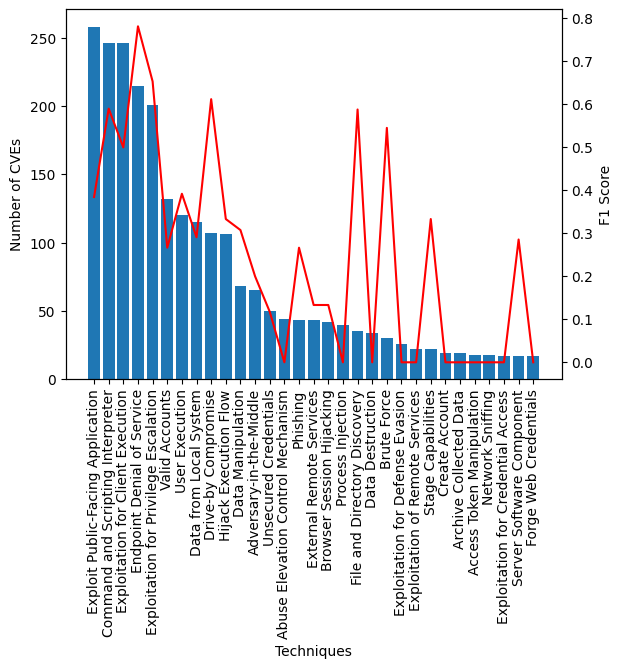

In [100]:
print_F1_based_on_distribution(y_test.values, prediction_rounded, y_train,  y_test.columns)

In [101]:
conf_matrix = multilabel_confusion_matrix(y_test.values, prediction_rounded)

Process Injection


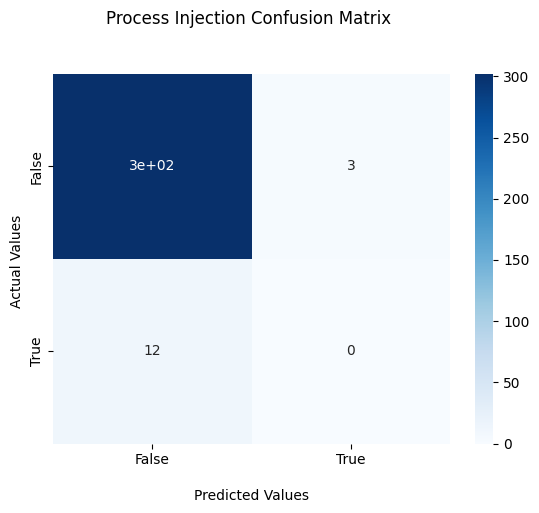

Access Token Manipulation


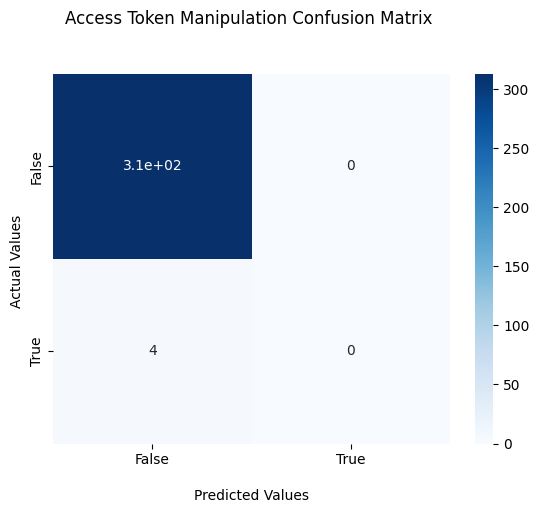

Hijack Execution Flow


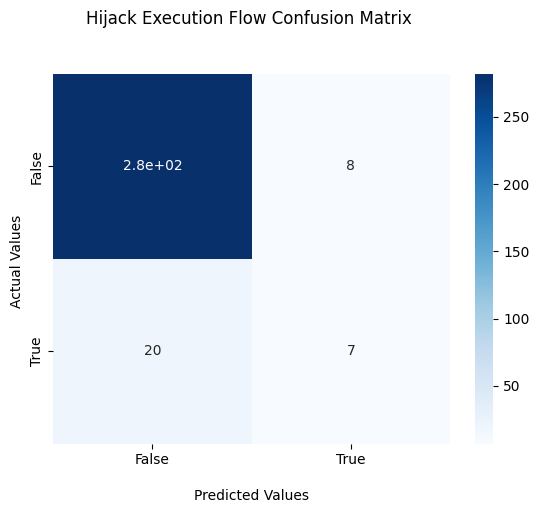

Data from Local System


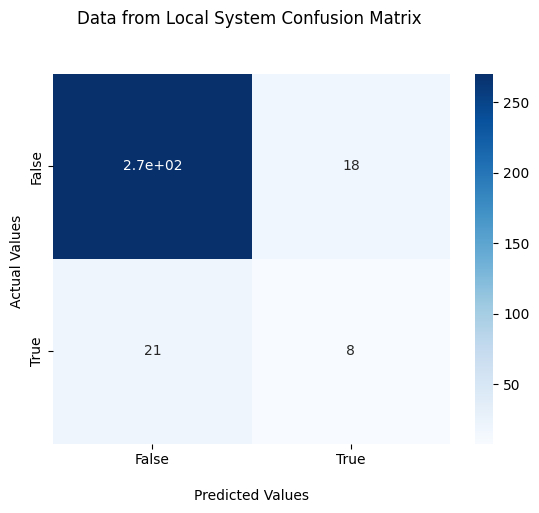

External Remote Services


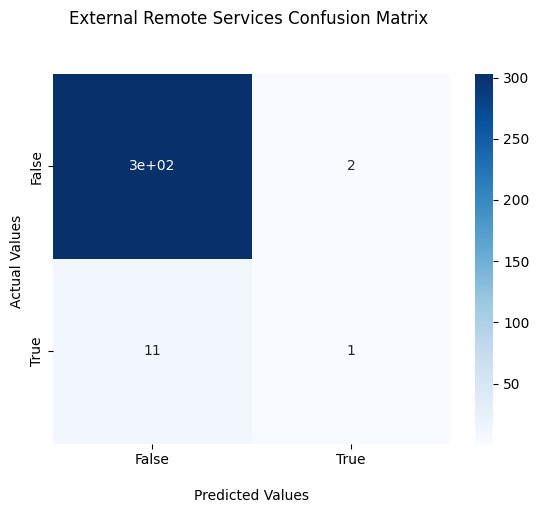

Data Manipulation


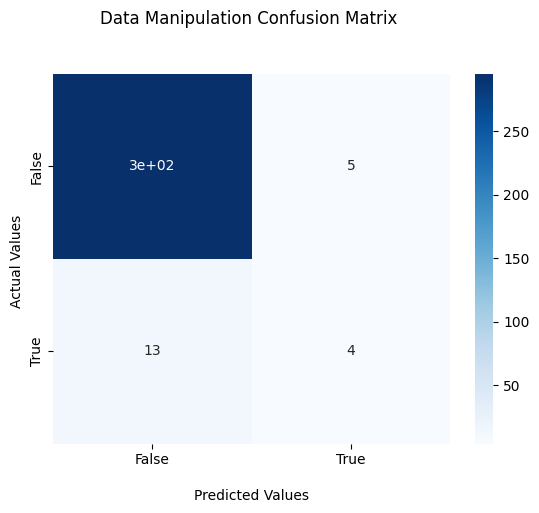

Network Sniffing


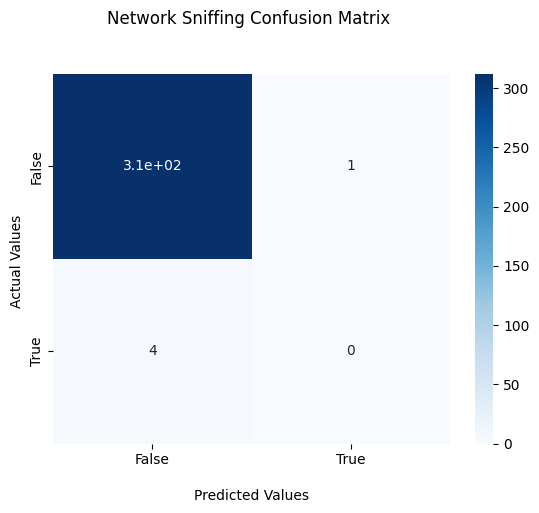

Exploitation for Privilege Escalation


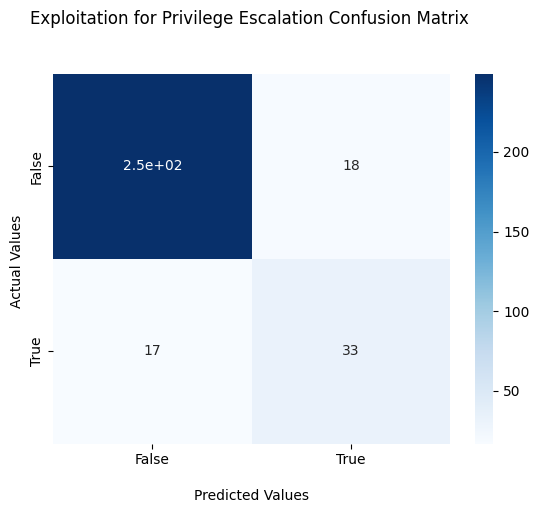

Command and Scripting Interpreter


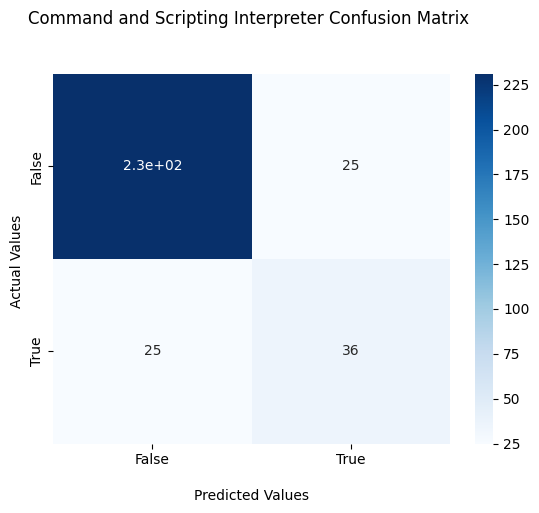

Phishing


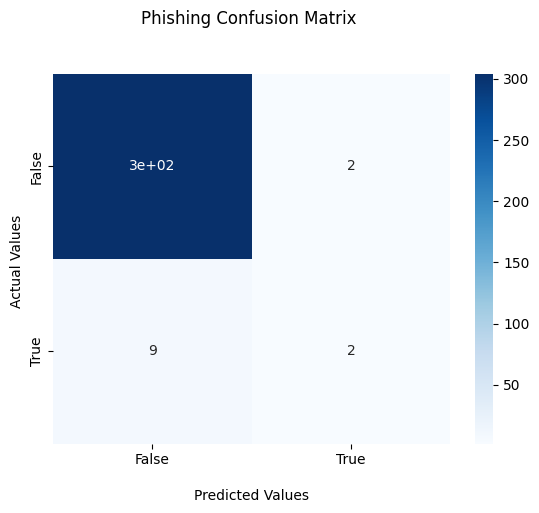

Server Software Component


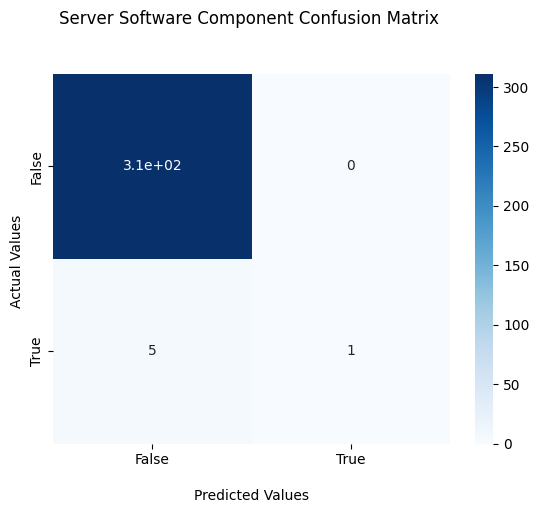

Archive Collected Data


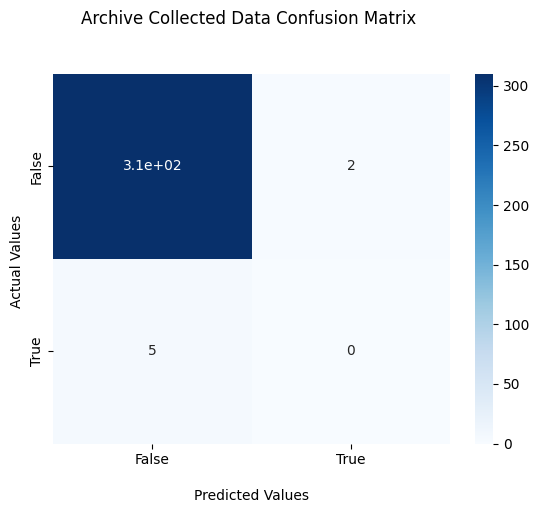

Data Destruction


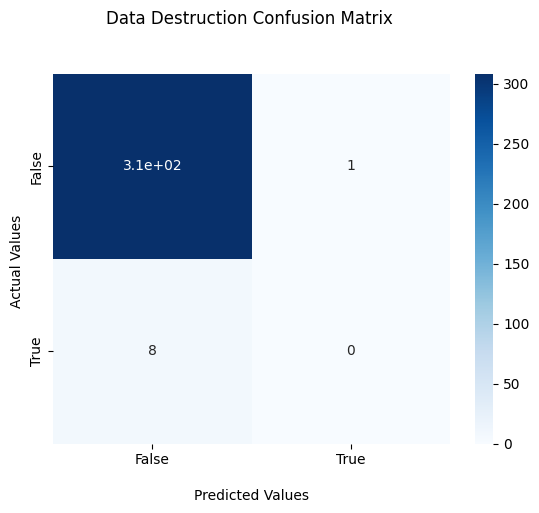

Browser Session Hijacking


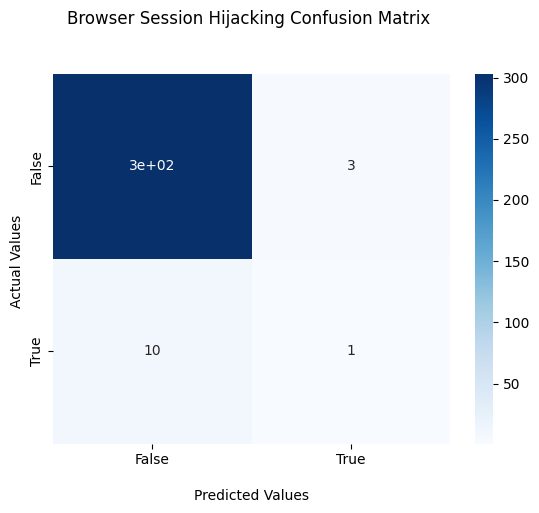

Exploitation for Credential Access


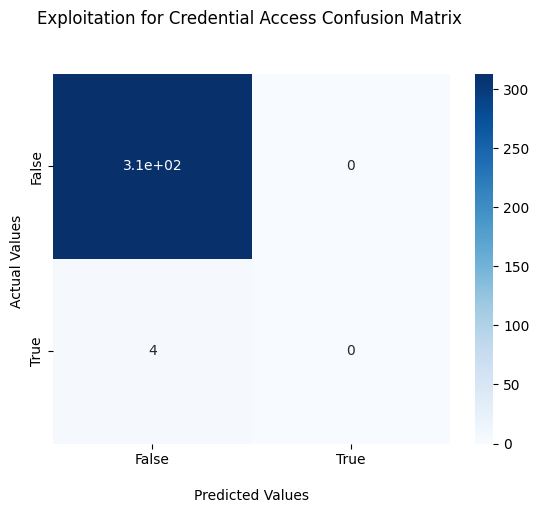

Abuse Elevation Control Mechanism


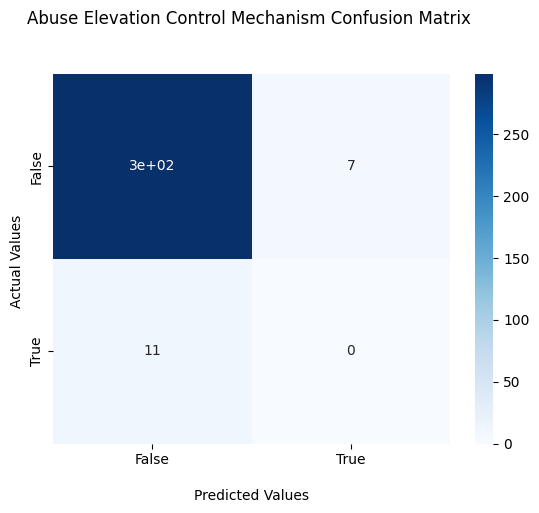

Adversary-in-the-Middle


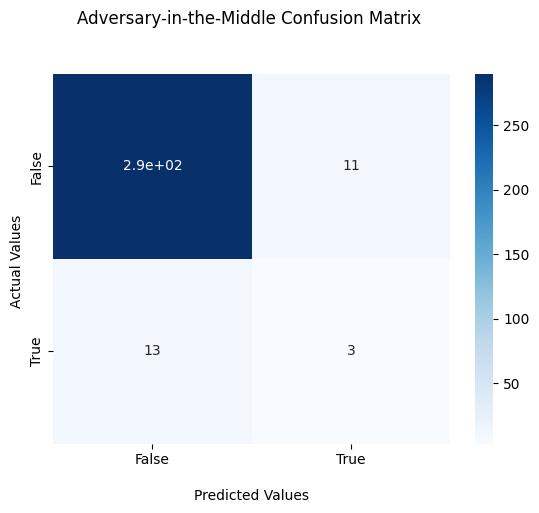

User Execution


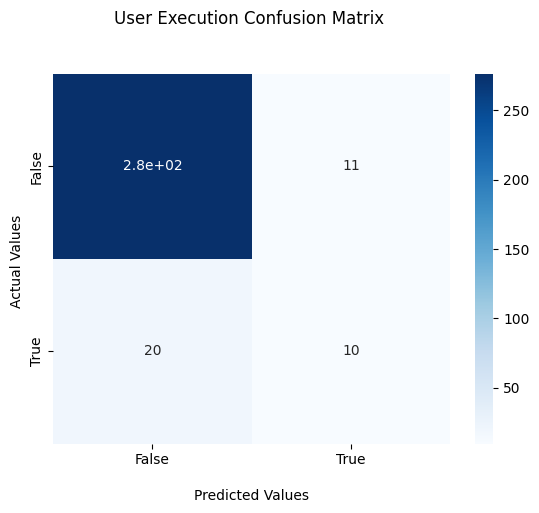

Unsecured Credentials


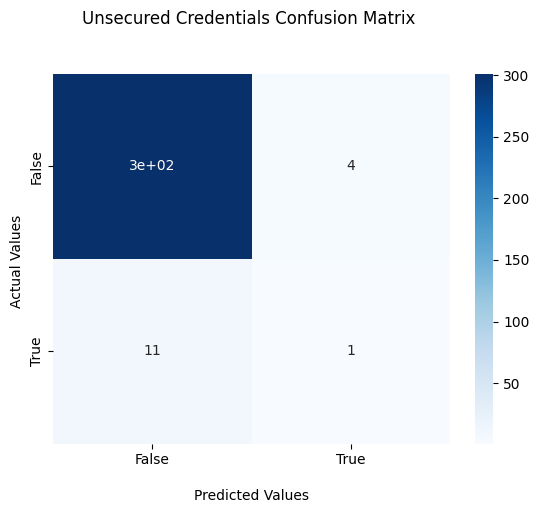

Brute Force


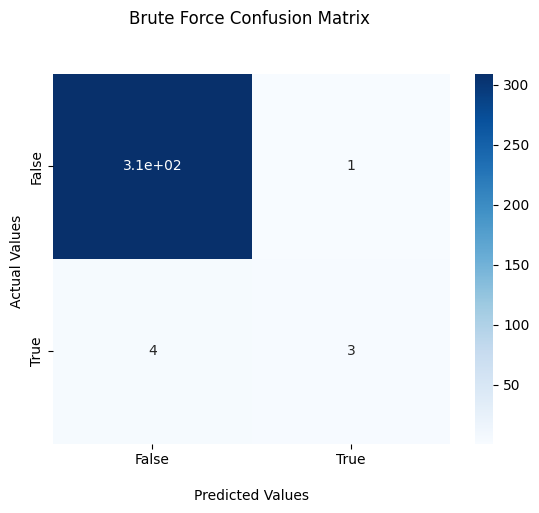

File and Directory Discovery


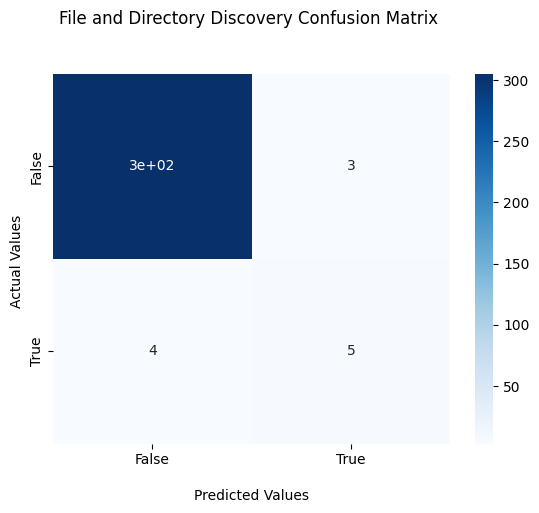

Valid Accounts


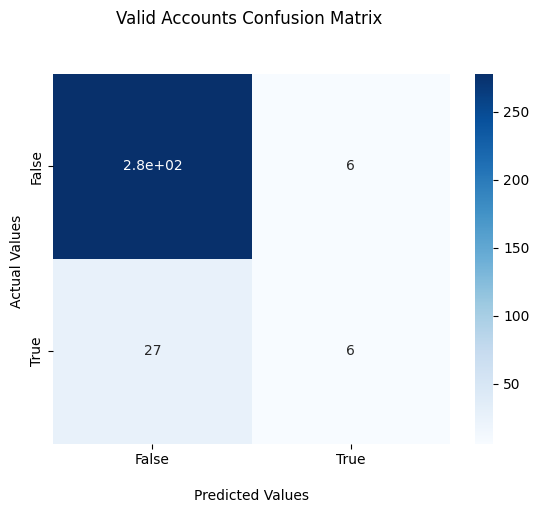

Exploitation for Defense Evasion


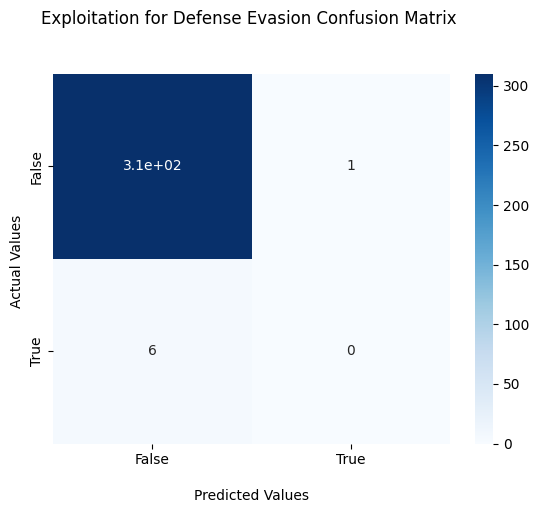

Create Account


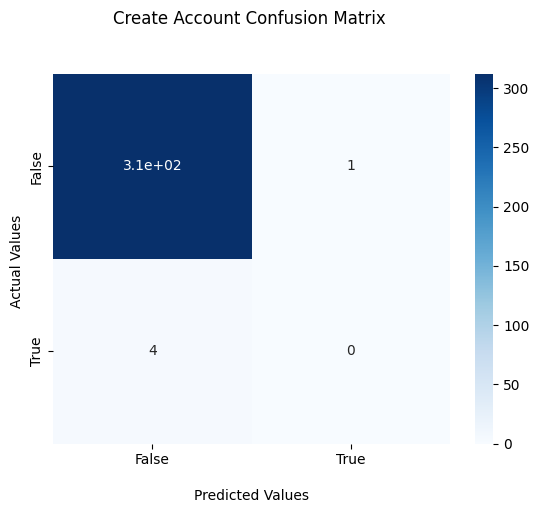

Endpoint Denial of Service


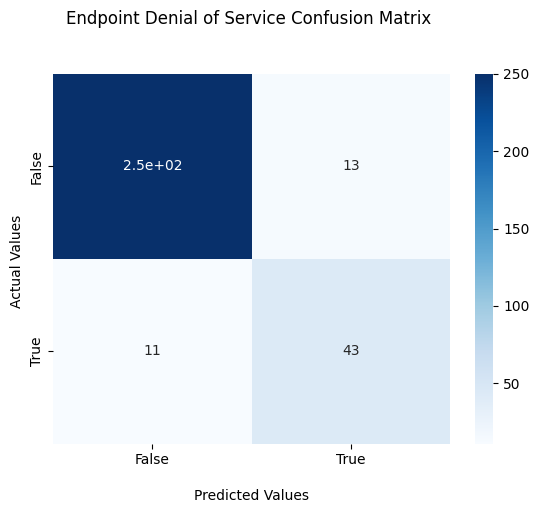

Drive-by Compromise


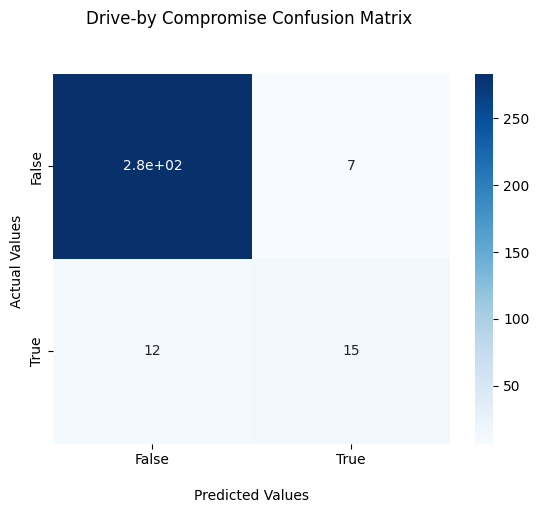

Exploitation for Client Execution


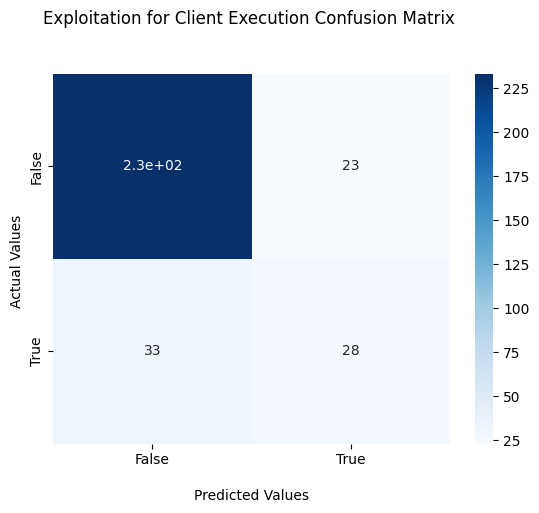

Exploitation of Remote Services


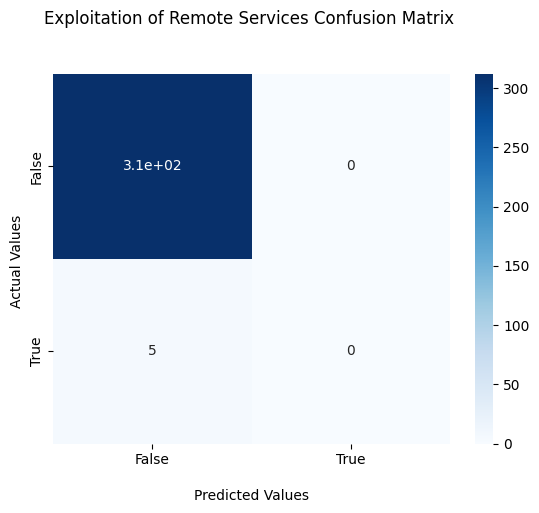

Stage Capabilities


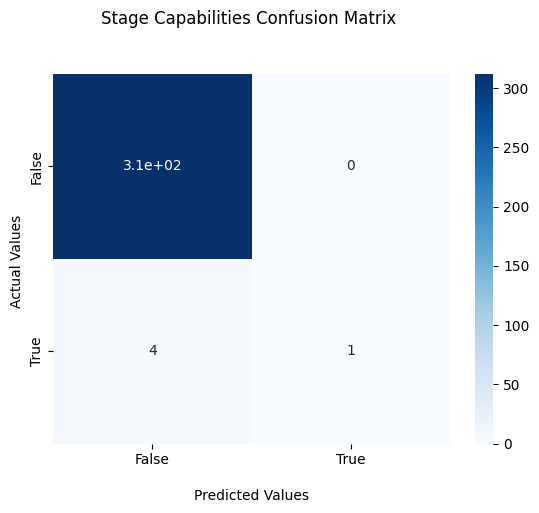

Exploit Public-Facing Application


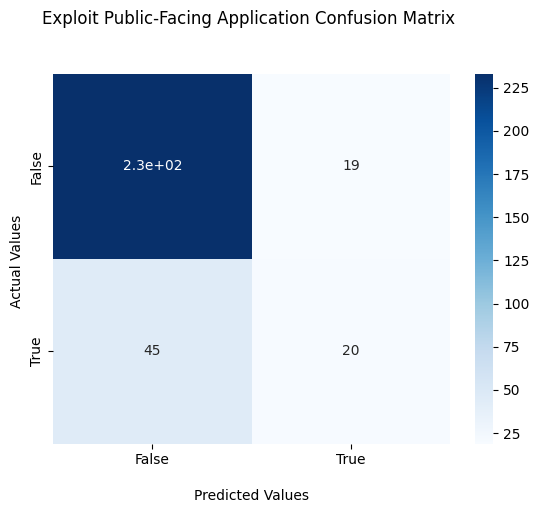

Forge Web Credentials


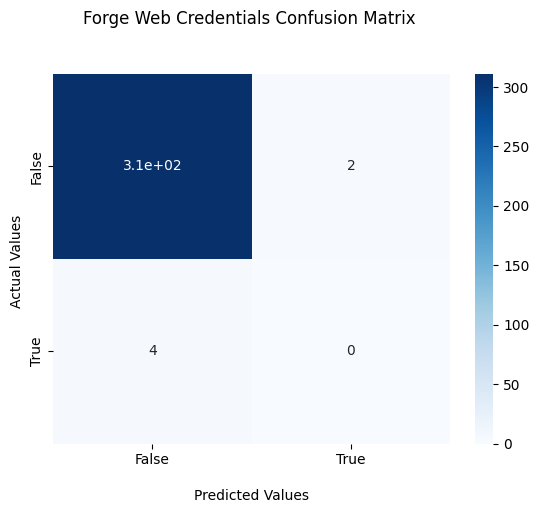

In [102]:
for i in range(31):
  print(y_test.columns[i])
  print_confusion_matrix(conf_matrix[i], y_test.columns[i])

In [103]:
from keras.models import Sequential
from keras.layers import Embedding, SpatialDropout1D, Conv1D, BatchNormalization, GlobalMaxPool1D, Dense
from keras.optimizers import Adam
import tensorflow as tf
import keras.backend as K
CNN_Word2Vec_extended_model = Sequential([
    Embedding(input_dim =embedding_matrix.shape[0], 
              input_length=maxlen, 
              output_dim=embedding_matrix.shape[1],
              weights=[embedding_matrix], 
              trainable=False),
    SpatialDropout1D(0.5),
    # ... 100 filters with a kernel size of 4 so that each convolution will consider a window of 4 word embeddings
    Conv1D(filters=100, kernel_size=4, padding='same', activation='relu'),
    #**batch normalization layer** normalizes the activations of the previous layer at each batch, 
    #i.e. applies a transformation that maintains the mean activation close to 0 and the activation standard deviation close to 1. 
    #It will be added after the activation function between a convolutional and a max-pooling layer.
    BatchNormalization(),
    GlobalMaxPool1D(),
   
    Dense(31, activation = 'sigmoid')
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [115]:
CNN_Word2Vec_extended_model.compile(loss='binary_crossentropy', 
                           optimizer=Adam(), 
                           metrics=['accuracy', f1])
history_extended = CNN_Word2Vec_extended_model.fit(X_train__extended_pad,
                    y_train_extended.values,
                    epochs=100,
                    batch_size=64,          
                    validation_data=(X_test_pad, y_test.values))


Epoch 1/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 9s 127ms/step - accuracy: 0.0522 - f1: 0.0718 - loss: 2.3245 - val_accuracy: 0.0126 - val_f1: 0.0981 - val_loss: 0.5099
Epoch 2/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 7s 116ms/step - accuracy: 0.1099 - f1: 0.0806 - loss: 0.2364 - val_accuracy: 0.0473 - val_f1: 0.1137 - val_loss: 0.4054
Epoch 3/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 7s 118ms/step - accuracy: 0.1877 - f1: 0.1319 - loss: 0.1777 - val_accuracy: 0.0820 - val_f1: 0.1254 - val_loss: 0.3403
Epoch 4/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 7s 117ms/step - accuracy: 0.2487 - f1: 0.1579 - loss: 0.1595 - val_accuracy: 0.1073 - val_f1: 0.1186 - val_loss: 0.2707
Epoch 5/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 7s 119ms/step - accuracy: 0.3137 - f1: 0.1955 - loss: 0.1447 - val_accuracy: 0.1609 - val_f1: 0.1244 - val_loss: 0.2257
Epoch 6/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 7s 121ms/step - accuracy: 0.3653 - f1: 0.2331 - loss: 0.1387 - val_accuracy: 0.2114 - val_f1: 0.1062 - val_loss: 0.2043
Epoch 7/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 7s 116m

In [116]:
prediction_extended = CNN_Word2Vec_extended_model.predict(X_test_pad)
prediction_extended_rounded = round_prediction(prediction_extended)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


In [117]:
print(accuracy_score(y_test.values, prediction_extended_rounded))

0.13564668769716087


In [118]:
print("F1 Score")
compute_metrics(prediction_extended_rounded, y_test.values, f1_score, y_test.columns, 20)

F1 Score


,Endpoint Denial of Service,Exploitation for Privilege Escalation,Command and Scripting Interpreter,Drive-by Compromise,File and Directory Discovery,Exploitation for Client Execution,Adversary-in-the-Middle,Stage Capabilities,Data from Local System,User Execution,Data Manipulation,Exploit Public-Facing Application,Brute Force,Archive Collected Data,Unsecured Credentials,Phishing,Valid Accounts,Hijack Execution Flow,Forge Web Credentials,Server Software Component
0,0.780952,0.619469,0.557143,0.542373,0.5,0.470588,0.444444,0.444444,0.415094,0.408163,0.4,0.378378,0.363636,0.333333,0.307692,0.3,0.297872,0.292683,0.285714,0.25


In [119]:

print("Recall Score")
compute_metrics(prediction_extended_rounded, y_test.values, recall_score, y_test.columns, 20)

Recall Score


,Endpoint Denial of Service,Exploitation for Privilege Escalation,Command and Scripting Interpreter,Drive-by Compromise,File and Directory Discovery,Stage Capabilities,Exploitation for Client Execution,Data from Local System,Adversary-in-the-Middle,Data Manipulation,Unsecured Credentials,User Execution,Exploit Public-Facing Application,Brute Force,Phishing,Forge Web Credentials,Hijack Execution Flow,Valid Accounts,Archive Collected Data,Browser Session Hijacking
0,0.759259,0.7,0.639344,0.592593,0.444444,0.4,0.393443,0.37931,0.375,0.352941,0.333333,0.333333,0.323077,0.285714,0.272727,0.25,0.222222,0.212121,0.2,0.181818


In [120]:
print("Precision Score")
compute_metrics(prediction_extended_rounded, y_test.values, precision_score, y_test.columns, 20)

Precision Score


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


,Archive Collected Data,Endpoint Denial of Service,Exploitation for Client Execution,File and Directory Discovery,Exploitation for Privilege Escalation,Adversary-in-the-Middle,User Execution,Server Software Component,Valid Accounts,Drive-by Compromise,Brute Force,Stage Capabilities,Command and Scripting Interpreter,Data Manipulation,Data from Local System,Exploit Public-Facing Application,Hijack Execution Flow,Phishing,Forge Web Credentials,Unsecured Credentials
0,1.0,0.803922,0.585366,0.571429,0.555556,0.545455,0.526316,0.5,0.5,0.5,0.5,0.5,0.493671,0.461538,0.458333,0.456522,0.428571,0.333333,0.333333,0.285714


In [121]:
print(f1_score(y_test.values, prediction_extended_rounded, average='weighted'))

0.41896822684592605


In [122]:
print(recall_score(y_test.values, prediction_extended_rounded, average='weighted'))

0.4


In [123]:
print(precision_score(y_test.values, prediction_extended_rounded, average='weighted'))

0.46802831513648263


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


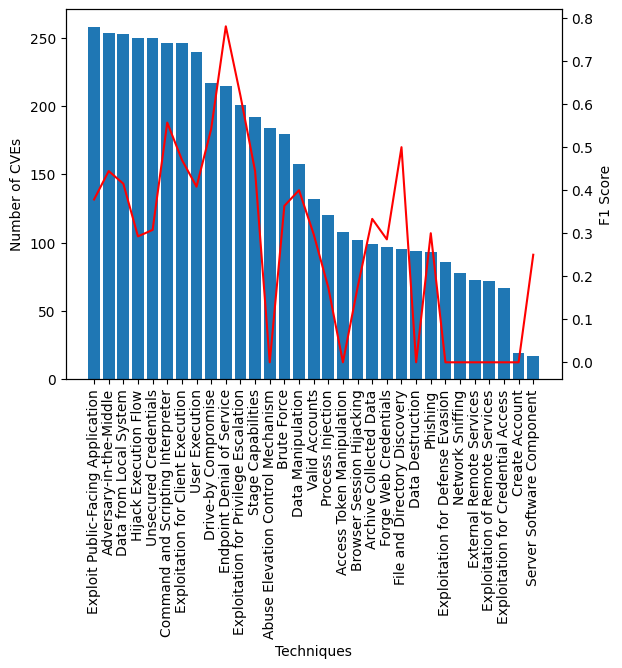

In [124]:
print_F1_based_on_distribution(y_test.values, prediction_extended_rounded, y_train_extended,  y_test.columns)

In [125]:

conf_matrix_extended = multilabel_confusion_matrix(y_test.values, prediction_extended_rounded)

Process Injection


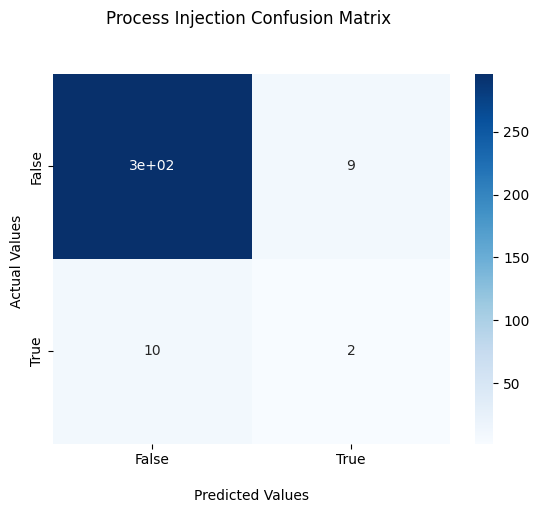

Access Token Manipulation


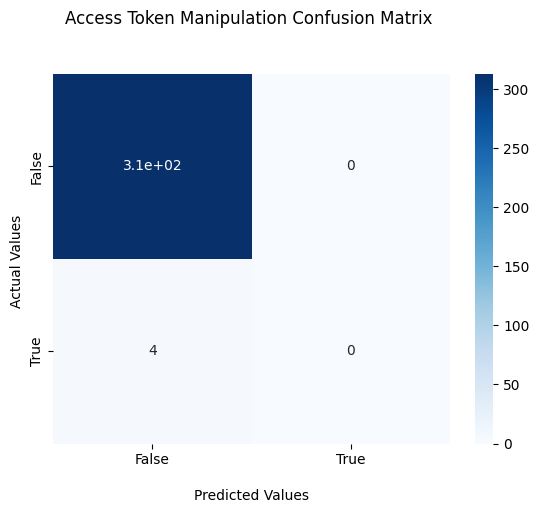

Hijack Execution Flow


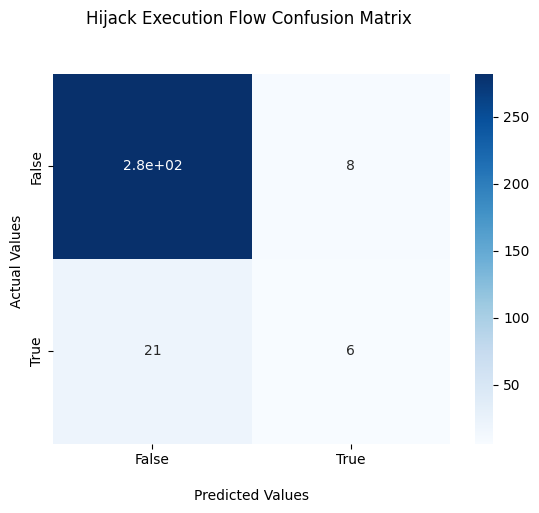

Data from Local System


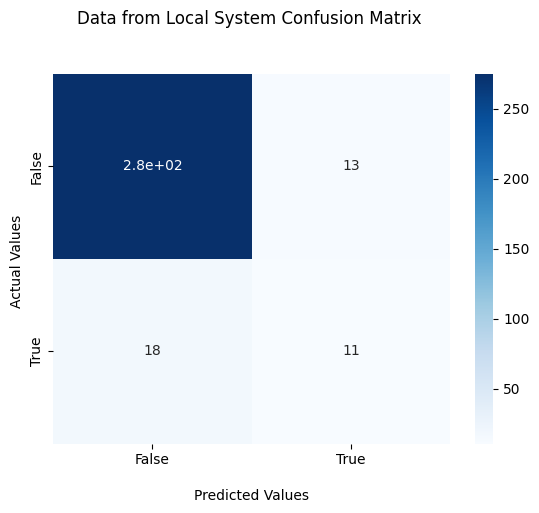

External Remote Services


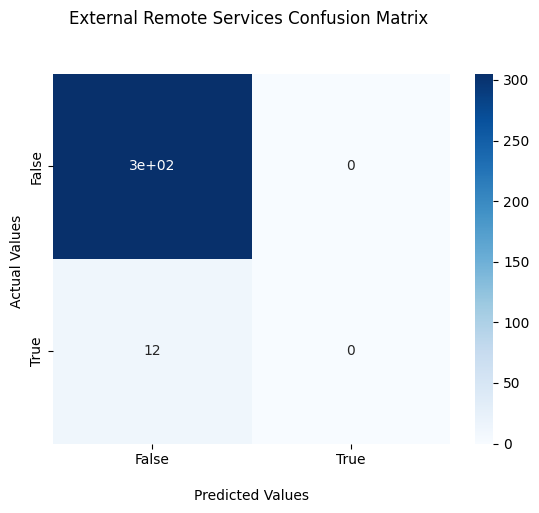

Data Manipulation


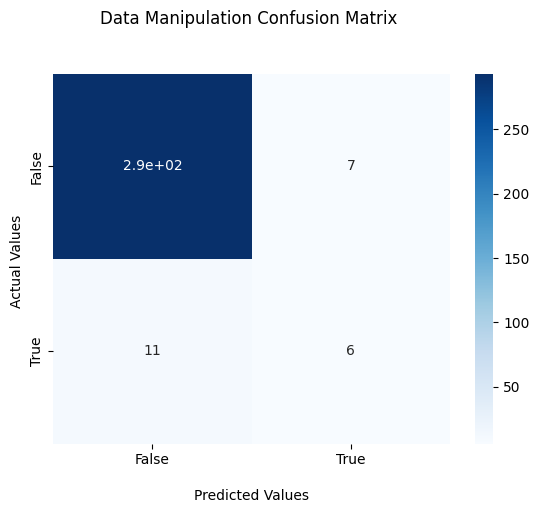

Network Sniffing


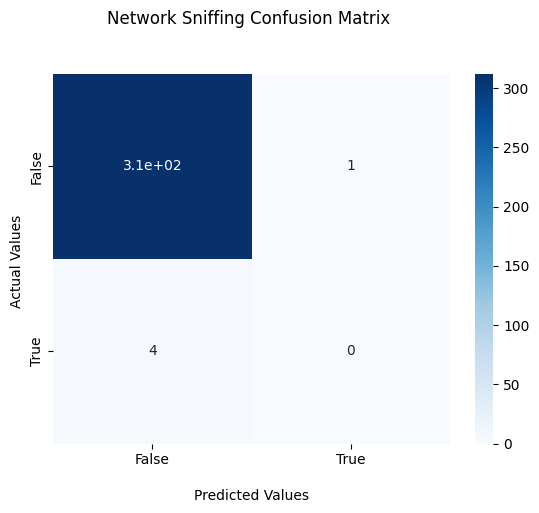

Exploitation for Privilege Escalation


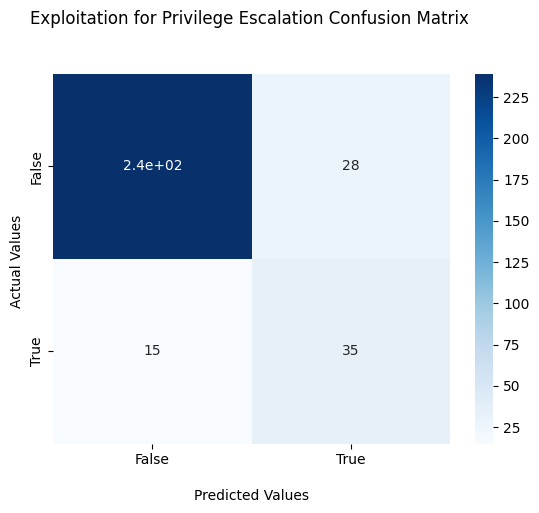

Command and Scripting Interpreter


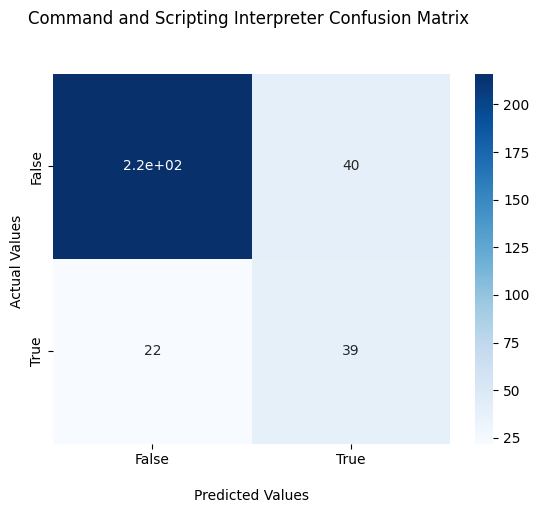

Phishing


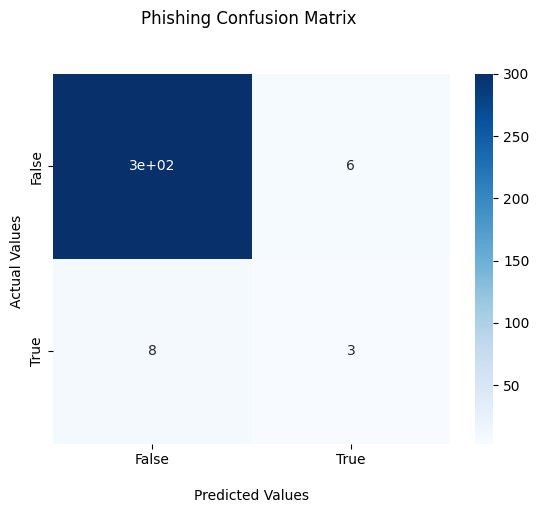

Server Software Component


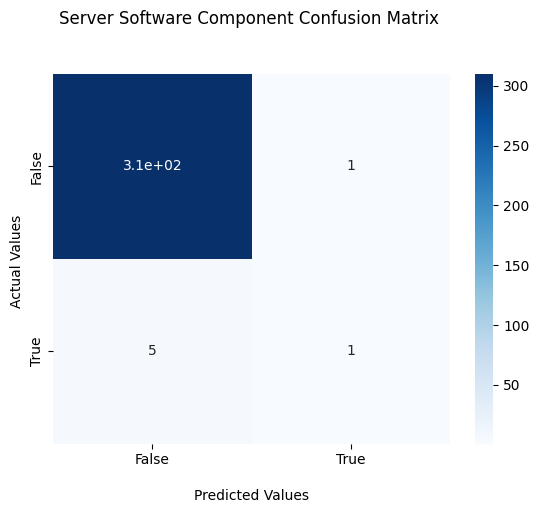

Archive Collected Data


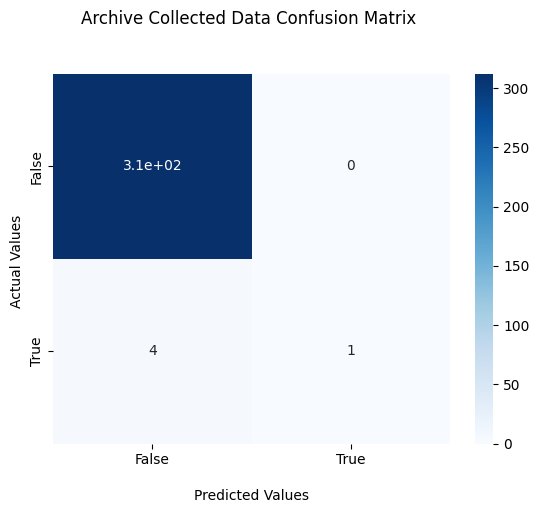

Data Destruction


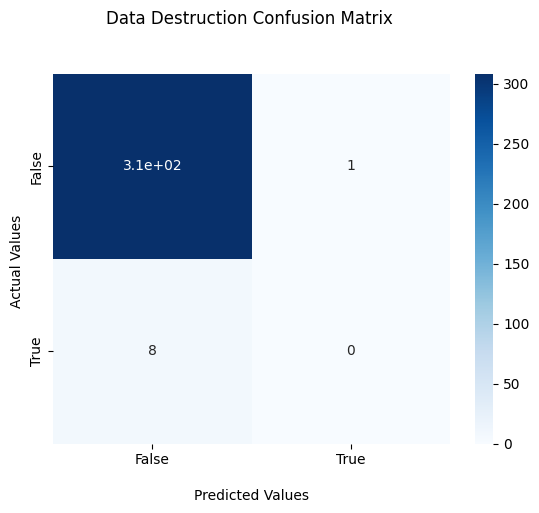

Browser Session Hijacking


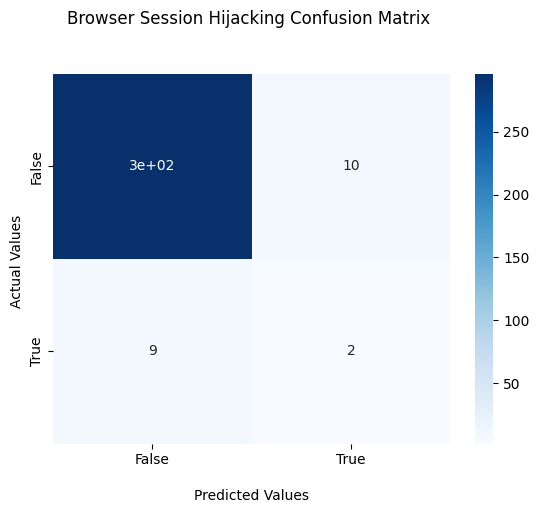

Exploitation for Credential Access


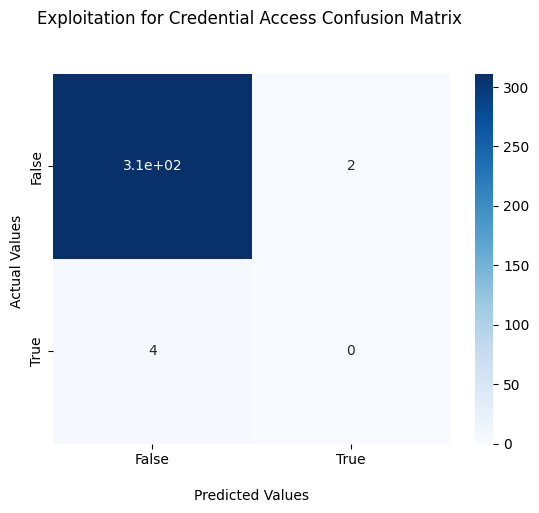

Abuse Elevation Control Mechanism


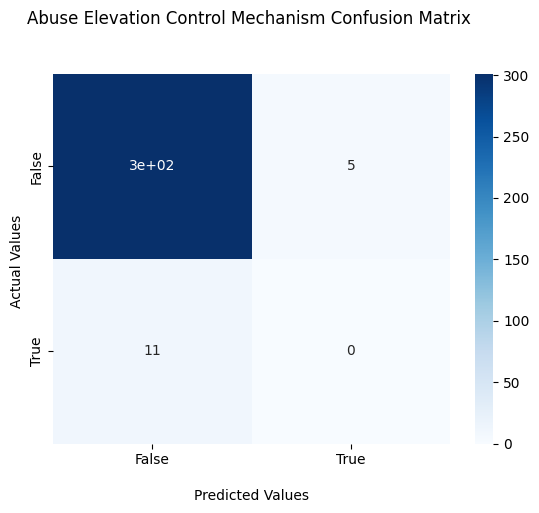

Adversary-in-the-Middle


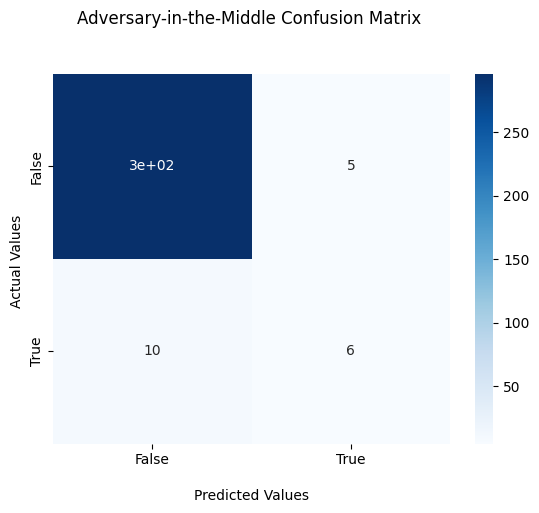

User Execution


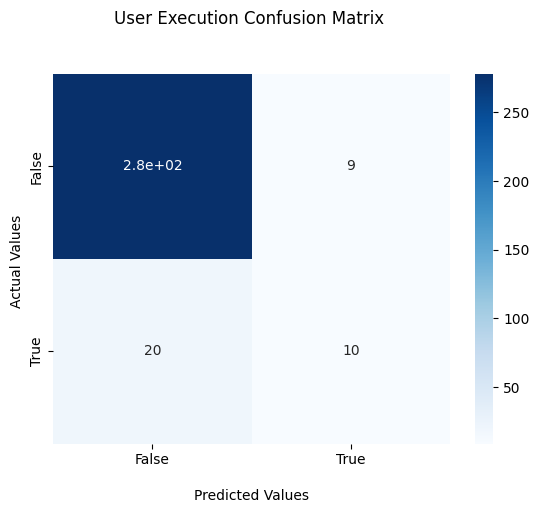

Unsecured Credentials


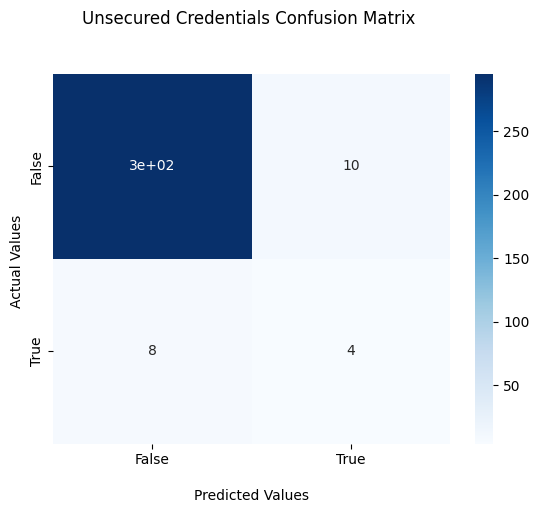

Brute Force


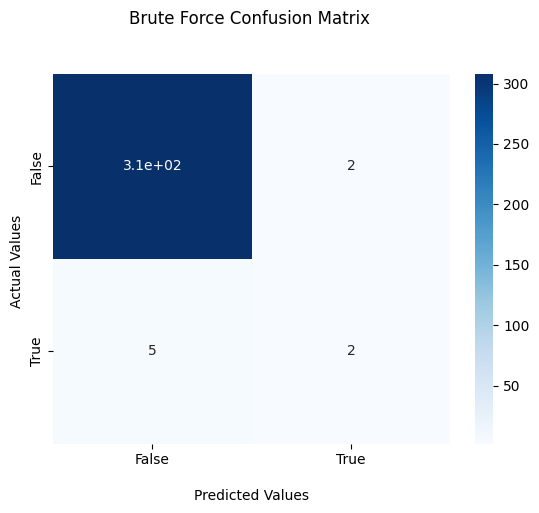

File and Directory Discovery


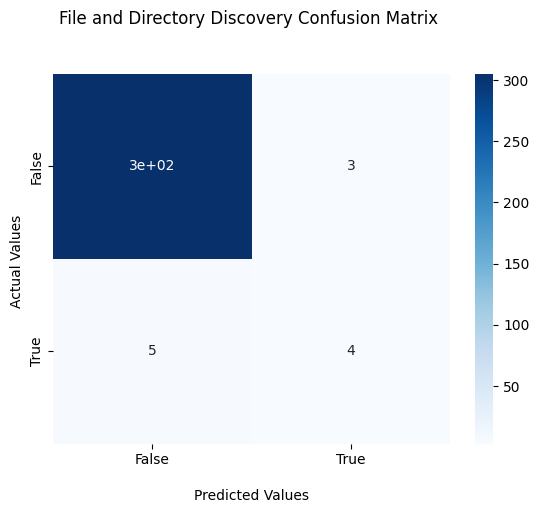

Valid Accounts


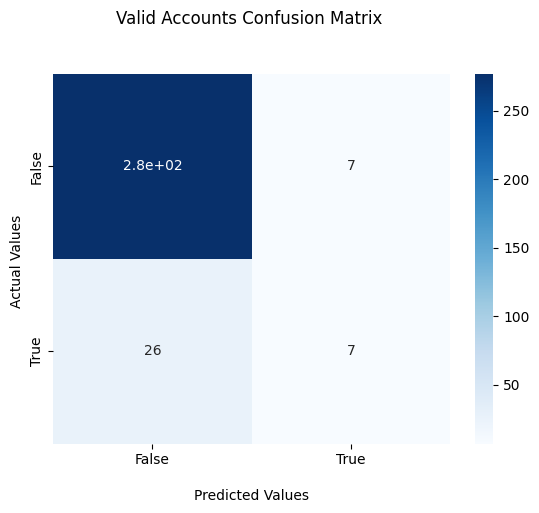

Exploitation for Defense Evasion


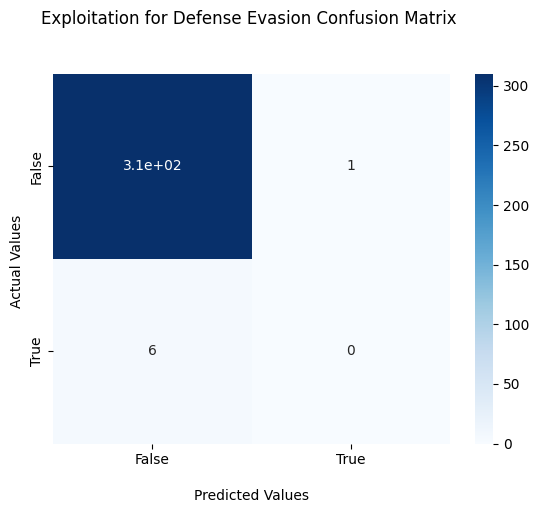

Create Account


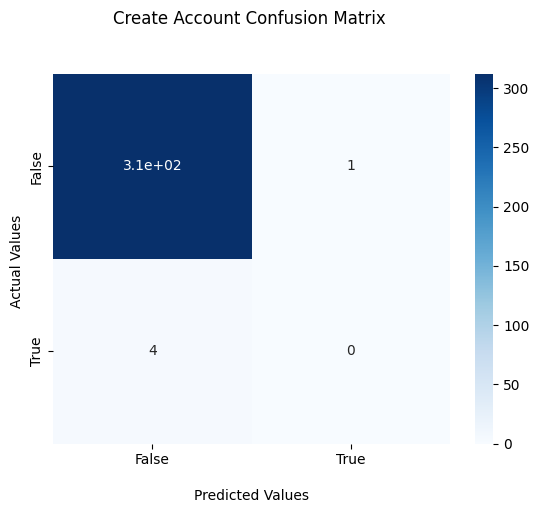

Endpoint Denial of Service


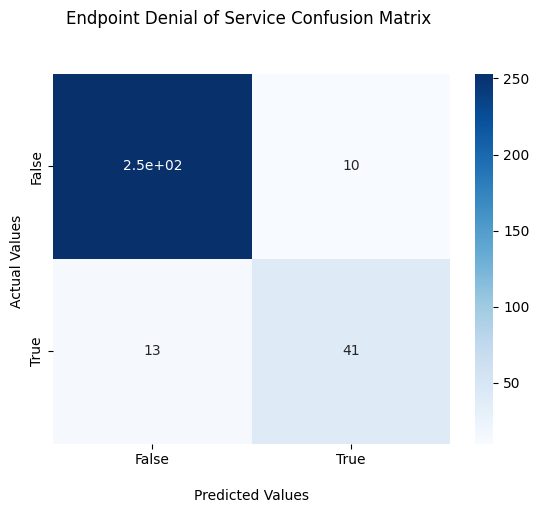

Drive-by Compromise


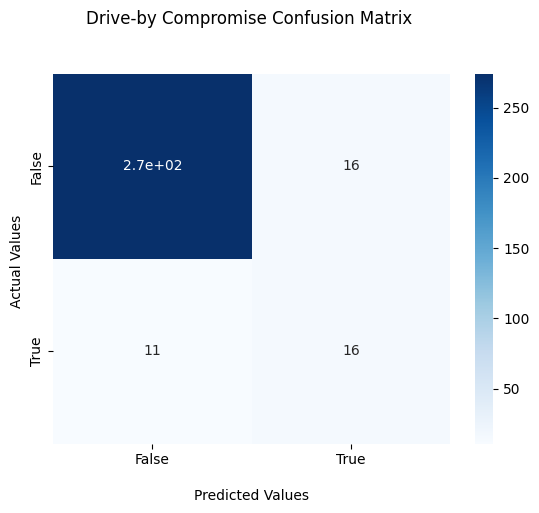

Exploitation for Client Execution


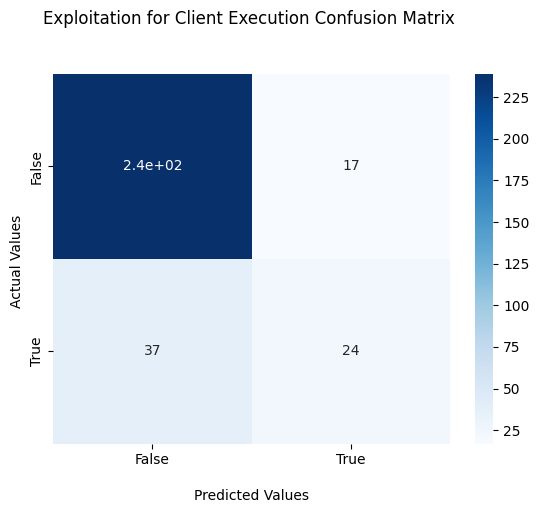

Exploitation of Remote Services


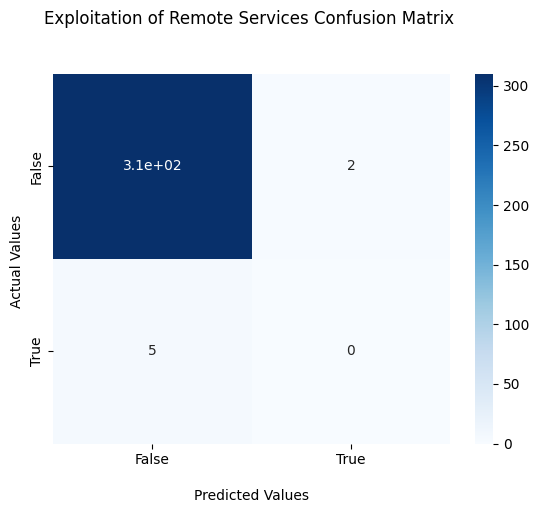

Stage Capabilities


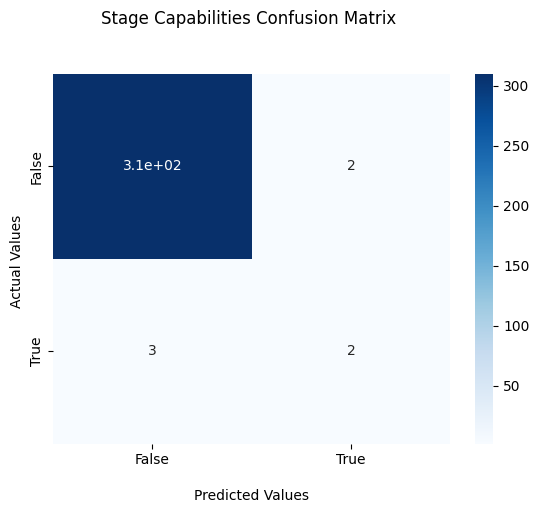

Exploit Public-Facing Application


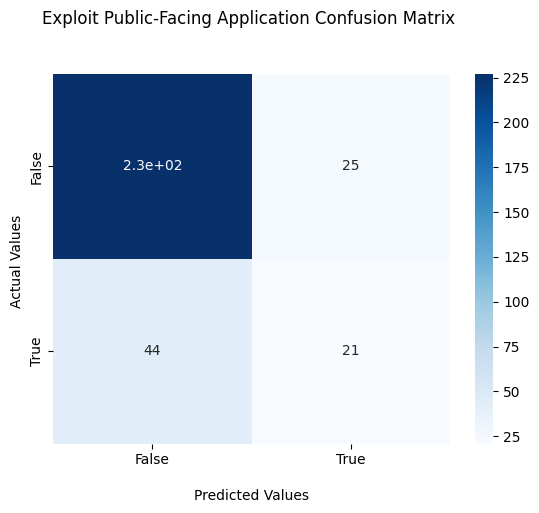

Forge Web Credentials


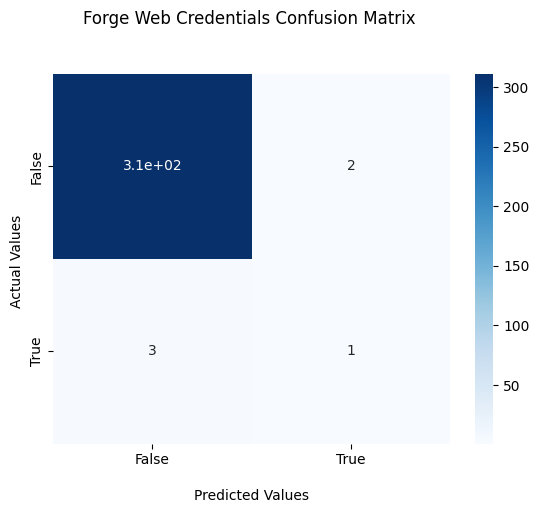

In [126]:

for i in range(31):
  print(y_test.columns[i])
  print_confusion_matrix(conf_matrix_extended[i], y_test.columns[i])